# All Figures
Central notebook for reproducing all paper figures.

## 1. Imports & Configuration

In [ ]:
import os
import sys
import json
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from scipy.stats import entropy, mannwhitneyu, rankdata, chi2_contingency
from sklearn.metrics import accuracy_score
from statsmodels.stats.multitest import multipletests

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import matplotlib.transforms as transforms
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('fontTools').setLevel(logging.ERROR)

# Make shared utils importable
sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
from utils.features import filter_feature_columns, custom_feature_scaling, get_probabilities, remove_constant_features
from utils.parsing import load_tables
from utils.process_tools import get_classification_scores
from utils.feature_analysis import (
    perform_mann_whitney_tests, perform_f_tests, perform_mutual_info_tests,
    residualize_features, rank_features_by_composite, rank_features_by_score,
    plot_feature_distributions, plot_feature_heatmap, plot_volcano,
    discover_feature_sets, load_feature_set, correlation_and_distance, cluster_features,
    plot_correlation_heatmap, plot_dendrogram
)
import utils.plotting


In [ ]:
# Font configuration
fm.fontManager.addfont(f'/home/{os.getenv("USER")}/.local/share/fonts/Arial.TTF')
plt.rcParams['font.family'] = 'Arial'

In [ ]:
# Matplotlib / display configuration
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)


## 2. Paths & Dataset Configuration

In [ ]:
BASE       = Path("/mnt/cbib/LNClassifier/paper")
DSET       = "gencode.v47.common.cdhit.cv"   # cross-validation dataset
REFERENCE  = "gencode.v47"
AVERAGE    = "macro"

RESULTS_DIR         = BASE / "results" / DSET
FIGURE_DIR          = RESULTS_DIR / "figures_notebook"
tables_dir          = RESULTS_DIR / "tables"
binary_table_file   = tables_dir / f"{DSET}_binary_class_table.tsv"
inference_info_file = RESULTS_DIR / "training" / f"{DSET}.inference_info.tsv"
uncertainty_dir     = RESULTS_DIR / "uncertainty_analysis"
te_features_file    = BASE / "te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv"
nbd_features_file   = BASE / "nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.corrected.csv"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 3. Data Loading

In [ ]:
def load_main_dataset(dataset_name, basedir=BASE, verbose=True):
    """Load main tables, labels, features, probabilities, and additional pipeline features."""
    tables   = load_tables(dataset_name)
    binary   = tables['binary'].set_index('seq_ID')
    pc_ids   = binary[binary['real'] == True].index.tolist()
    lnc_ids  = binary[binary['real'] == False].index.tolist()
    ids_with_class = pc_ids + lnc_ids

    features_df = tables['full_table'].set_index('seq_ID').loc[ids_with_class]
    probs       = get_probabilities(features_df).dropna()
    labels      = pd.DataFrame(index=probs.index)
    labels['coding_class'] = labels.index.isin(pc_ids).astype(int)
    labels['biotype']      = labels['coding_class'].map({1: 'coding', 0: 'lncRNA'})

    if verbose:
        print(f"PC: {len(pc_ids):,}  |  lncRNA: {len(lnc_ids):,}  |  total: {len(ids_with_class):,}")
    return {
        'binary': binary, 'features': features_df.loc[probs.index],
        'probs': probs, 'labels': labels,
        'pc_ids': pc_ids, 'lnc_ids': lnc_ids
    }


def load_additional_features(dataset_name, basedir=BASE, verbose=True):
    """Load TE and NBD pipeline features and entropy/uncertainty table."""
    pipelines = {
        'te_pipeline': 'te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv',
        'nbd_pipeline': 'nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.corrected.csv',
        'entropy':      f"results/{dataset_name}/features/entropy/{dataset_name}_uncertainty_analysis.tsv",
    }
    out = {}
    for key, rel_path in pipelines.items():
        path = basedir / rel_path
        if path.exists():
            df = pd.read_csv(path, sep='\t' if path.suffix == '.tsv' else ',', index_col=0)
            out[key] = df
            if verbose:
                print(f"  {key}: {df.shape}")
        else:
            if verbose:
                print(f"  WARNING: {key} not found at {path}")
    return out

In [ ]:
# Load all datasets
dataset  = load_main_dataset(DSET)
addl     = load_additional_features(DSET)

binary      = dataset['binary']
features_df = dataset['features']
probs       = dataset['probs']
labels      = dataset['labels']
pc_ids      = dataset['pc_ids']
lnc_ids     = dataset['lnc_ids']
ids_with_class = pc_ids + lnc_ids

feature_cols         = filter_feature_columns(features_df)
selected_features_df = features_df[feature_cols].copy()

te_features  = addl.get('te_pipeline')
nbd_features = addl.get('nbd_pipeline')
entropy_df   = addl.get('entropy')

if te_features is not None:
    te_features = te_features.loc[te_features.index.isin(probs.index)].reindex(probs.index)
    te_features.fillna(0, inplace=True)
if nbd_features is not None:
    nbd_features = nbd_features.loc[nbd_features.index.isin(probs.index)].reindex(probs.index)
    nbd_features.rename(columns={'motif_types_present': 'n_motif_types'}, inplace=True)
if entropy_df is not None:
    entropy_df = entropy_df.loc[entropy_df.index.isin(probs.index)].reindex(probs.index)

# Raw binary classification table (used for tool performance figures)
labels_file = pd.read_csv(binary_table_file, sep='\t')
labels_file.head(3)

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
PC: 66,376  |  lncRNA: 45,276  |  total: 111,652
  te_pipeline: (385659, 173)
  entropy: (111652, 13)
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_lncDC', 'Hexamer_score_ORF_T2_lncDC', 'Hexamer_score_OR

,seq_ID,fold,rnasamba,feelnc,p_cpat,l_cpat,lncDC,ss_lncDC,mrnn,lncrnabert,plncpro,ss_lncfinder,lncfinder,real
0,ENST00000000412.8,fold1,True,True,True,True,True,True,True,True,True,True,True,True
1,ENST00000002596.6,fold1,True,True,True,True,True,True,True,True,True,True,True,True
2,ENST00000002829.8,fold1,True,True,True,True,True,True,True,True,True,True,True,True


## 4. Figures

### Figure 1 – Tool Performance (CV)
*Source: `004_tool_performance_CV.ipynb`, last plot*

In [ ]:
# ── Prerequisite: load per-fold binary tables ──────────────────────────────
CV_BASE = BASE / "results" / DSET / "testing"
N_FOLDS = 5

cv_binary_dfs = {}
for fold in range(1, N_FOLDS + 1):
    fold_dir = CV_BASE / f"fold{fold}" / "tables"
    binary_file = fold_dir / f"fold{fold}_binary_class_table.tsv"
    if binary_file.exists():
        df = pd.read_csv(binary_file, sep="\t")
        if "seq_ID" in df.columns:
            df = df.set_index("seq_ID")
        cv_binary_dfs[f"fold{fold}"] = df
        print(f"Loaded fold{fold}: {len(df)} transcripts")
    else:
        print(f"Warning: {binary_file} not found")

print(f"\nTotal folds loaded: {len(cv_binary_dfs)}")

Loaded fold1: 22346 transcripts
Loaded fold2: 22321 transcripts
Loaded fold3: 22334 transcripts
Loaded fold4: 22332 transcripts
Loaded fold5: 22319 transcripts

Total folds loaded: 5


In [ ]:
# ── Compute classification scores per fold ───────────────────────────────────
cv_scores = {}
for fold_name, df in cv_binary_dfs.items():
    scores = get_classification_scores(df, average="macro")
    cv_scores[fold_name] = scores

all_fold_scores = pd.concat(cv_scores, names=["fold", "tool"])

# Aggregate
metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
cv_aggregated = all_fold_scores.groupby(level="tool")[metric_cols].agg(["mean", "std"])
cv_aggregated.columns = ["_".join(col).strip() for col in cv_aggregated.columns.values]
cv_aggregated = cv_aggregated.sort_values("f1_score_mean", ascending=False)

# Select best variant per tool
has_underscore = cv_aggregated.index.str.contains("_")
cv_aggregated["mode"]      = cv_aggregated.index.str.split("_").str[0].where(has_underscore, "")
cv_aggregated["tool_name"] = cv_aggregated.index.str.split("_").str[-1]
cv_aggregated = (cv_aggregated.sort_values("f1_score_mean", ascending=False)
                              .reset_index()
                              .groupby("tool_name").first()
                              .sort_values("f1_score_mean", ascending=False)
                              .set_index("tool")
                              .drop(columns="mode"))

# Rename to display names
tool_names = {
    'lncrnabert': "lncRNABERT", 'mrnn': "mRNN", 'feelnc': "FEELnc",
    'rnasamba': "RNAsamba", 'ss_lncfinder': "LncFinder", 'ss_lncDC': "LncDC",
    'plncpro': "PlncPro", 'l_cpat': "CPAT"
}
cv_aggregated.index = cv_aggregated.index.map(tool_names)
cv_aggregated

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std
tool,,,,,,,,,,
lncRNABERT,0.950077,0.000721,0.950002,0.001091,0.946999,0.000784,0.950002,0.001091,0.948406,0.000760
PlncPro,0.933749,0.000618,0.93128,0.000542,0.931314,0.000824,0.93128,0.000542,0.931294,0.000606
mRNN,0.922957,0.001475,0.922726,0.001274,0.918654,0.001657,0.922726,0.001274,0.920506,0.001484
FEELnc,0.916088,0.001691,0.916321,0.002008,0.911323,0.001663,0.916321,0.002008,0.913531,0.001787
RNAsamba,0.912066,0.001268,0.915639,0.000972,0.906623,0.001249,0.915639,0.000972,0.909925,0.001191
LncFinder,0.898175,0.002307,0.902037,0.002826,0.892528,0.002377,0.902037,0.002826,0.895828,0.002441
LncDC,0.813088,0.002438,0.836505,0.002014,0.82929,0.001648,0.836505,0.002014,0.812868,0.002407
CPAT,0.779932,0.002479,0.742676,0.003086,0.806382,0.002431,0.742676,0.003086,0.751637,0.003282


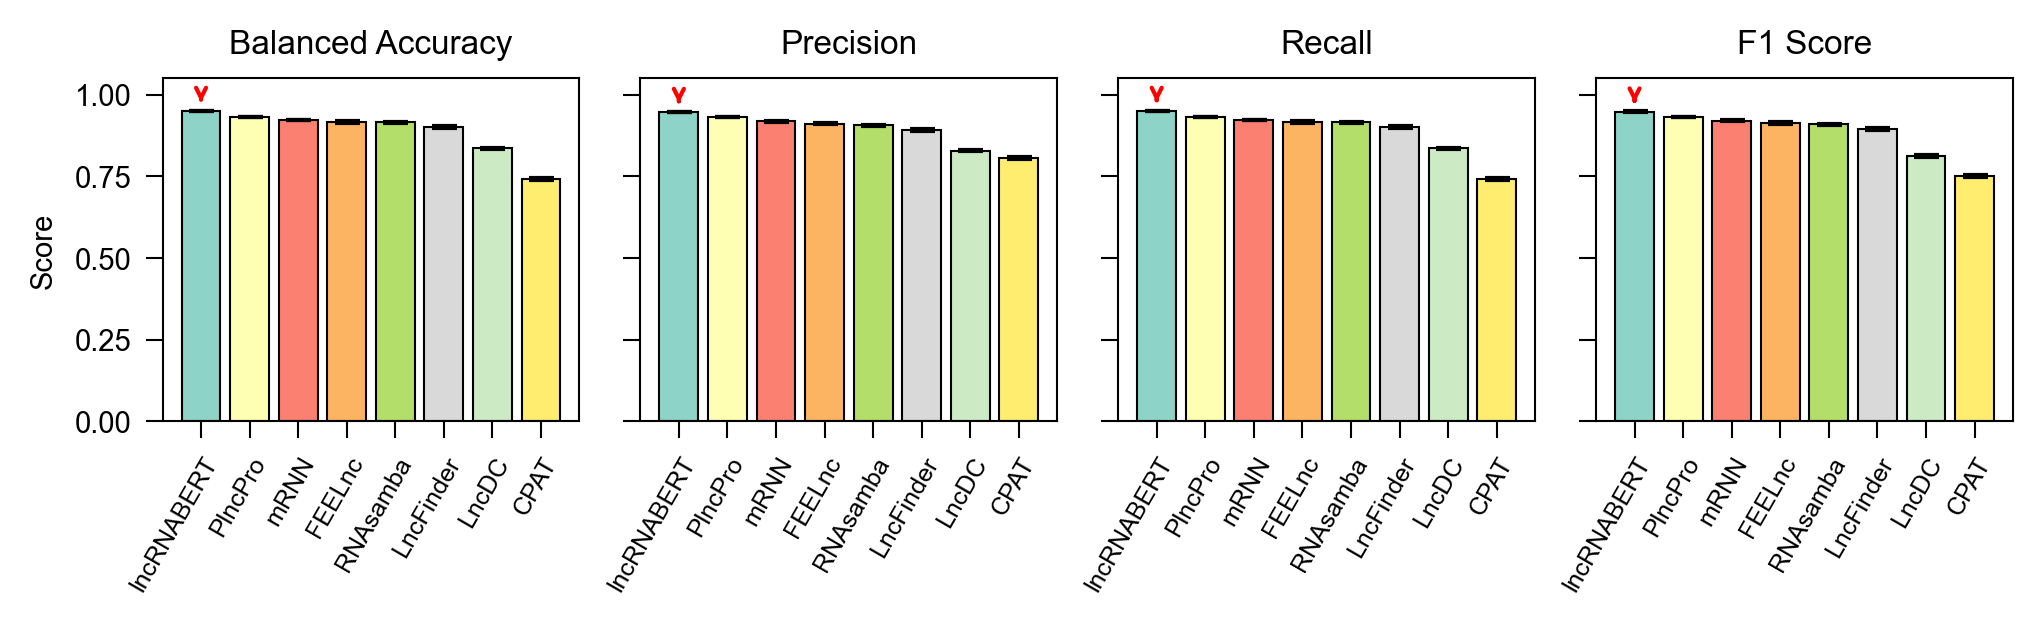

In [ ]:
# ── Plot: CV aggregated performance ─────────────────────────────────────────
layout = [["balanced_accuracy", "precision", "recall", "f1_score"]]
fig_h_cm, fig_w_cm = 5, 17

fig, axes_map = plt.subplot_mosaic(layout,
                                   figsize=(fig_w_cm/2.54, fig_h_cm/2.54),
                                   constrained_layout=True,
                                   dpi=300,
                                   layout="constrained")

metrics  = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
n_tools  = len(cv_aggregated)
colors   = plt.cm.Set3(np.linspace(0, 1, n_tools))
flat_layout = [item for sublist in layout for item in sublist]

for metric in metrics:
    if metric not in flat_layout:
        continue
    ax       = axes_map[metric]
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"
    x_pos    = np.arange(n_tools)

    bars = ax.bar(x_pos, cv_aggregated[mean_col], yerr=cv_aggregated[std_col],
                  capsize=3, alpha=1, color=colors, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(cv_aggregated.index, rotation=60, ha="right", fontsize=6)

    dx = 0.07
    offset = transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)

    ax.set_ylim([0, 1.05])
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.label_outer()
    ax.set_title(metric.replace("_", " ").title(), fontsize=8)

    top_idx   = np.argmax(cv_aggregated[mean_col].to_numpy())
    top_bar   = bars[top_idx]
    center_x  = top_bar.get_x() + top_bar.get_width() / 2
    yerr_val  = float(cv_aggregated[std_col].iloc[top_idx])
    top_y     = top_bar.get_height() + yerr_val
    ax.annotate("", xy=(center_x, top_y), xytext=(center_x, top_y + 0.06),
                arrowprops=dict(arrowstyle="->", color="red", lw=1), clip_on=False)

plt.savefig(FIGURE_DIR / "performance_CV.pdf", dpi=300, format='pdf')
plt.show()

### Figure 2 – Classification Consensus
*Source: `004_correct_classification.ipynb`, last plot*

In [ ]:
# ── Prerequisite: compute correct-by-class ──────────────────────────────────
label_cols = ['rnasamba', 'feelnc', 'l_cpat', 'ss_lncDC', 'mrnn', 'lncrnabert', 'plncpro', 'ss_lncfinder']

correct = pd.DataFrame(index=labels_file.index)
for c in label_cols:
    correct[c] = labels_file[c] == labels_file["real"]
correct["n_correct"] = correct.sum(axis=1)
correct['real']      = labels_file['real']

correct_by_class = (correct.groupby("n_correct")["real"]
                            .value_counts()
                            .unstack()
                            .sort_index(ascending=False)
                            .rename(columns={True: "coding", False: "lncRNA"}))

all_or_none = pd.DataFrame(columns=correct_by_class.columns)
all_or_none.loc["None"]      = correct_by_class.loc[0]
all_or_none.loc["All"]       = correct_by_class.loc[8]
all_or_none.loc["Ambiguous"] = correct_by_class.loc[list(range(1, 8))].sum()
all_or_none["order"] = [2, 0, 1]
all_or_none = all_or_none.sort_values("order").drop(columns="order")
all_or_none

real,lncRNA,coding
All,21823,42972
Ambiguous,22967,22915
None,486,489


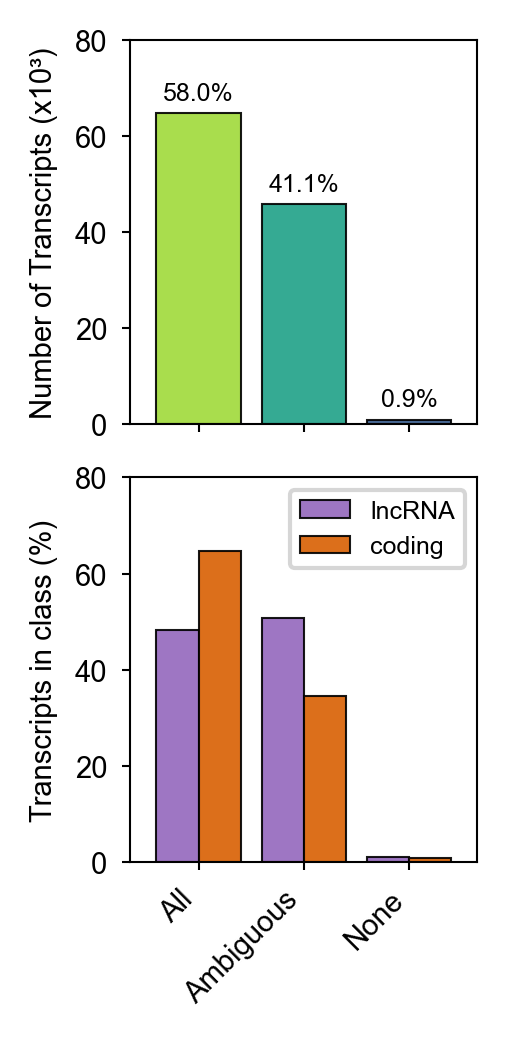

In [ ]:
# ── Plot: Classification consensus ──────────────────────────────────────────
fig_width_cm, fig_height_cm = 4, 8.5
colors_cls = ['#9467bd', '#d95f02']  # lncRNA (purple), coding (orange)

plt.rcParams.update({
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5,
    'font.weight': 'normal', 'axes.labelweight': 'normal',
    'axes.titlesize': 9, 'axes.labelsize': 7,
    'lines.linewidth': 0.5, 'lines.markersize': 5,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'font.size': 6, 'legend.fontsize': 6,
})

viridis    = plt.get_cmap('viridis', 8)
vir_colors = [viridis(6), viridis(4), viridis(2)]

fig, axes = plt.subplots(2, 1, figsize=(fig_width_cm/2.54, fig_height_cm/2.54), dpi=300, sharex=True)

all_or_none_total = all_or_none.sum(axis=1) / 1000
all_or_none_total.plot.bar(ax=axes[0], color=vir_colors, width=0.8, alpha=0.9, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Number of Transcripts (x10³)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticks(np.arange(0, all_or_none_total.max() + 20, 20))
axes[0].set_ylim(0, 80)

total_transcripts = all_or_none.sum().sum() / 1000
for container in axes[0].containers:
    for bar in container:
        height = bar.get_height()
        if np.isfinite(height) and height > 0:
            axes[0].annotate(
                f'{height/total_transcripts*100:.1f}%',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', xytext=(0, 2), textcoords='offset points')

all_or_none_class_pct = all_or_none.div(all_or_none.sum(axis=0), axis=1) * 100
all_or_none_class_pct.plot.bar(stacked=False, ax=axes[1], color=colors_cls, width=0.8,
                                alpha=0.9, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Transcripts in class (%)')
axes[1].legend(title='')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticks(np.arange(0, all_or_none_total.max() + 20, 20))
axes[1].set_ylim(0, 80)

for ax in axes:
    ax.tick_params(width=0.5, length=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.savefig(FIGURE_DIR / "correct_classification.pdf", dpi=300, format="pdf")
plt.show()

### Figure 3 – Uncertainty Space Scatter
*Source: `005_entropy_binning_plots.ipynb`, last plot*

In [ ]:
# ── Prerequisite: compute thresholds and entropy_class ──────────────────────
LOW_TH  = 10
HIGH_TH = 90

low_th       = np.percentile(entropy_df["H_pred"], LOW_TH)
high_th_pred = np.percentile(entropy_df["H_pred"], HIGH_TH)
high_th_bald = np.percentile(entropy_df["I_bald"],  HIGH_TH)

entropy_df["entropy_class"] = 'other'
entropy_df.loc[entropy_df["H_pred"] < low_th, "entropy_class"] = "low"
entropy_df.loc[(entropy_df["H_pred"] > high_th_pred) & (entropy_df["I_bald"] > high_th_bald), "entropy_class"] = "high"

print(f"Low H_pred threshold:  {low_th:.4f}")
print(f"High H_pred threshold: {high_th_pred:.4f}")
print(f"High I_bald threshold: {high_th_bald:.4f}")
entropy_df["entropy_class"].value_counts()

Low H_pred threshold:  0.1030
High H_pred threshold: 0.8951
High I_bald threshold: 0.3984


entropy_class
other    96440
low      11166
high      4046
Name: count, dtype: int64

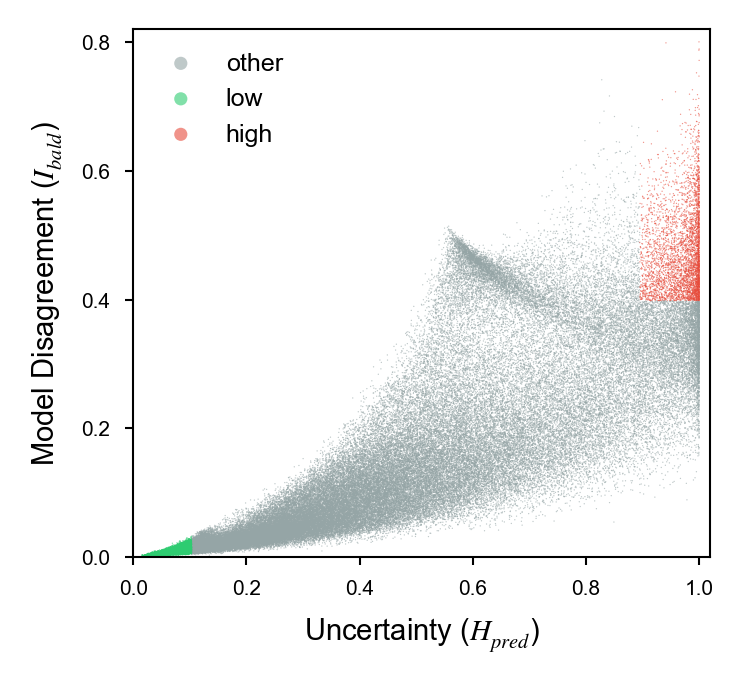

In [ ]:
# ── Plot: Uncertainty (H_pred) vs Model Disagreement (I_bald) scatter ───────
fig_w_cm, fig_h_cm = 6, 5.5
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(figsize=(fig_w_cm/2.54, fig_h_cm/2.54), dpi=300, constrained_layout=True)
df = entropy_df.copy()

for category in df["entropy_class"].unique():
    mask = df["entropy_class"] == category
    ax.scatter(df.loc[mask, "H_pred"], df.loc[mask, "I_bald"],
               marker='o',
               facecolors=utils.plotting.COLORS["entropy_class"][category],
               edgecolors='none', linewidths=0,
               label=category, alpha=0.6, s=0.1, rasterized=True)

ax.legend(markerscale=10, frameon=False)
ax.set_xlabel(r'Uncertainty ($\mathit{H}_{\mathit{pred}}$)', fontsize=7)
ax.set_xlim(0, 1.02)
ax.set_xticks(np.arange(0, 1.1, 0.2))
ax.set_ylabel(r'Model Disagreement ($\mathit{I}_{\mathit{bald}}$)', fontsize=7)
ax.set_ylim(0, 0.82)
ax.set_yticks(np.arange(0, 0.81, 0.2))
ax.tick_params(width=0.5, length=2)
ax.tick_params(axis="both", which="major", labelsize=5)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig(FIGURE_DIR / "entropy_bald_scatter.pdf", dpi=300, format='pdf')
plt.show()

### Figures 4–6 – Statistical Feature Tests
*Source: `020_feature_stat_tests_*.fix.ipynb` notebooks*

**Shared prerequisites** (run once, reused for all three figures below).

In [ ]:
# ── Shared config for statistical feature tests ──────────────────────────────
FDR_METHOD = 'fdr_bh'
FDR_ALPHA  = 0.01

OUTPUT_DIR_STATS = BASE / f'results/{DSET}/features/simple_analysis/H_pred_th10-90/'
OUTPUT_DIR_STATS.mkdir(parents=True, exist_ok=True)

# ── Combined feature matrix (main + TE + NBD) ────────────────────────────────
original_full    = pd.concat([selected_features_df, te_features, nbd_features], axis=1)
full_feature_set = original_full.copy()
full_feature_set = full_feature_set.loc[:, ~full_feature_set.columns.duplicated(keep='first')]
full_feature_set.fillna(0, inplace=True)
full_feature_set = full_feature_set.apply(pd.to_numeric, errors='coerce')

numeric_cols     = full_feature_set.select_dtypes(include=[np.number]).columns
constant_feats   = full_feature_set[numeric_cols].nunique()
constant_feats   = constant_feats[constant_feats <= 1].index.tolist()
full_feature_set = full_feature_set[numeric_cols].drop(columns=constant_feats)
print(f"Feature matrix: {full_feature_set.shape}")

# ── Separate categorical vs. scalar features ─────────────────────────────────
cat_substrings   = ['_has_', '_present']
cat_col_names    = ["ORF_frame_l_cpat"]
cat_cols         = [c for c in full_feature_set.columns
                    if any(s in c for s in cat_substrings) or c in cat_col_names]
scalar_cols      = full_feature_set.columns.difference(cat_cols).tolist()
print(f"  Categorical: {len(cat_cols)} | Scalar: {len(scalar_cols)}")

Feature matrix: (111652, 286)
  Categorical: 15 | Scalar: 271


In [ ]:
# ── Shared helpers ────────────────────────────────────────────────────────────
def vargha_delaney_A(d1, d2):
    """Vargha-Delaney A statistic."""
    n1, n2 = len(d1), len(d2)
    U = mannwhitneyu(d1, d2, method="auto").statistic
    return U / (n1 * n2)


def run_stat_tests(scalar_feat, cat_feat, grp1_idx, grp2_idx,
                   fdr_method=FDR_METHOD, fdr_alpha=FDR_ALPHA):
    """Run Mann-Whitney U + Chi-squared tests and apply FDR correction."""
    d1 = scalar_feat.loc[grp1_idx]
    d2 = scalar_feat.loc[grp2_idx]

    stat, pval = mannwhitneyu(d2, d1, alternative="two-sided")
    vda        = vargha_delaney_A(d2.values, d1.values)
    mannu_df   = pd.DataFrame({'statistic': stat, 'p_value': pval, 'vda': vda}, index=d1.columns)

    c1, c2 = cat_feat.loc[grp1_idx], cat_feat.loc[grp2_idx]
    chi2_rows = []
    for col in c1.columns:
        ct   = pd.crosstab(pd.concat([c1[col], c2[col]]),
                           pd.concat([pd.Series([0]*len(c1), index=c1.index),
                                      pd.Series([1]*len(c2), index=c2.index)]))
        chi2_stat, chi2_pval, _, _ = chi2_contingency(ct)
        n         = len(c1) + len(c2)
        cramers_v = np.sqrt(chi2_stat / (n * (min(ct.shape) - 1))) if min(ct.shape) > 1 else 0
        if ct.shape == (2, 2):
            a, b = ct.iloc[0, 0] + 0.5, ct.iloc[0, 1] + 0.5
            c, d = ct.iloc[1, 0] + 0.5, ct.iloc[1, 1] + 0.5
            odds_ratio = (a * d) / (b * c)
        else:
            odds_ratio = np.nan
        chi2_rows.append({'feature': col, 'statistic': chi2_stat, 'p_value': chi2_pval,
                          'cramers_v': cramers_v, 'odds_ratio': odds_ratio})
    chi2_df = pd.DataFrame(chi2_rows).set_index('feature')

    mannu_df['abs_vda']    = abs(mannu_df['vda'] - 0.5)
    mannu_df['rank']       = rankdata(mannu_df['abs_vda'])
    mannu_df['rank_perc']  = mannu_df['rank'] / len(mannu_df) * 100
    mannu_df['test']       = 'Mann-Whitney U'
    chi2_df['rank']        = rankdata(chi2_df['cramers_v'])
    chi2_df['rank_perc']   = chi2_df['rank'] / len(chi2_df) * 100
    chi2_df['test']        = 'Chi-squared'

    combined = pd.concat([mannu_df, chi2_df], axis=0)
    combined['adjusted_p_value'] = multipletests(combined['p_value'], method=fdr_method, alpha=fdr_alpha)[1]
    combined['significant']      = combined['adjusted_p_value'] < fdr_alpha
    combined = combined.sort_values('rank_perc', ascending=False)
    return mannu_df, chi2_df, combined


def build_clustered_mannu(combined_df, cluster_file, mann_tidy_columns):
    """Merge Mann-Whitney results with feature clusters and deduplicate."""
    cluster_df     = pd.read_csv(cluster_file, index_col=0)
    mann_tidy_cols = mann_tidy_columns + ["abs_vda"]
    clustered      = (combined_df.loc[combined_df["test"] == 'Mann-Whitney U', mann_tidy_cols]
                               .sort_values('abs_vda', ascending=False)
                               .merge(cluster_df["cluster_0.25"], left_index=True,
                                      right_index=True, how='left'))
    length_cluster = clustered[clustered.index == 'RNA_size_feelnc']['cluster_0.25'].values
    if length_cluster.size > 0:
        to_remove = clustered[clustered['cluster_0.25'] == length_cluster[0]].index.difference(['RNA_size_feelnc'])
        clustered = clustered.drop(index=to_remove)
    return clustered.sort_values('abs_vda', ascending=False).groupby('cluster_0.25').head(1)


CLUSTER_FILE     = BASE / "results" / DSET / "features/clustering/feature_clusters_at_distances.csv"
#MANN_TIDY_COLS   = ["adjusted_p_value", "rank_perc", "test", "vda", "interpretation", "significant"]
MANN_TIDY_COLS   = ["adjusted_p_value", "rank_perc", "test", "vda", "significant"]

FEATURE_LABEL_DICT = {
    # Continuous features
    'ORF_T1_length_lncDC': 'ORF length (type 1)', 'RNA_size_feelnc': 'Transcript length',
    'Signal.Min_lncfinder': 'Minimum frame signal', 'SS.pct.dist_lncfinder': 'Log. distance to coding SS',
    'Signal.Q1_lncfinder': 'Q1 of frame signal', 'Signal.Q2_lncfinder': 'Q2 of frame signal',
    'SS.lnc.dist_lncfinder': 'Log. distance to lncRNA SS', 'MFE_lncfinder': 'Minimum free energy',
    'Signal.Max_lncfinder': 'Maximum frame signal', 'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
    'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 1)', 'ORF_T0_length_lncDC': 'ORF length (type 0)',
    'ORF_l_cpat': 'ORF length (CPAT)', 'ORF.Max.Len_lncfinder': 'Max. ORF length',
    'Seq.pct.Dist_lncfinder': 'Log. distance to coding seqs.', 'Seq.lnc.Dist_lncfinder': 'Log. distance to lncRNA seqs.',
    'Fickett_l_cpat': 'Fickett score (CPAT)', 'Hexamer_l_cpat': 'Hexamer score (CPAT)',
    'Signal.Peak_lncfinder': 'Peak frame signal', 'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
    'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)', 'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
    'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)', 'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
    'Hexamer_score_ORF_T2_lncDC': 'Hexamer score (ORF type 2)', 'kmerScore_12mer_feelnc': '12-mer k-mer score',
    'ORF.Max.Cov_lncfinder': 'Max. ORF coverage', 'SS.Dist.Ratio_lncfinder': 'Ratio of Distance coding vs lncRNA SS',
    'ORF_T2_length_lncDC': 'ORF length (type 2)',
    'all_Frame_Entropy_plncpro': 'BLAST hit frame entropy', 'all_Bitscore_plncpro': 'Sum of BLAST hit bitscores',
    # Continuous features from TE or NBD pipelines
    'global_gaps_max': 'Max gap length between rep. elements', 
    'total_nonb_count': 'Total non-B DNA motifs', 'ir_gaps_mean_pct': 'Mean gap cvg. between IRs',
    'str_mean_length_pct': 'Mean coverage of STRs', 'ir_max_length_pct': 'Max coverage of an IR',
    'str_max_length_pct': 'Max coverage of a STR', 'global_rm_total_length': 'Total length covered by repeats',
    # Categorical features from TE or NBD pipelines
    'te_has_ltr': 'LTR', 'gq_present': 'G-quadruplex', 'lctr_has_simple_repeat': 'Simple Repeat',
    'z_present': 'Z-DNA', 'te_has_line': 'LINE', 'tri_present': 'Triplex DNA',
    'dr_present': 'Direct Repeat', 'mr_present': 'Mirror Repeat',
    'str_present': 'Short Tandem Repeat', 'lctr_has_low_complexity': 'Low Complexity Region',
    'lctr_has_satellite': 'Satellite', 'te_has_dna': 'DNA Transposon',
    'te_has_sine': 'SINE', 'te_has_srprna': 'srpRNA', 'apr_present': 'A-Phased Repeat',
    # Additional features from SHAP analysis
    'te_gaps_max': 'Longest gap between TEs', 'te_count': 'TE count',
    'te_ltr_count': 'LTR count', 'te_max_hit_length': 'Max length of a TE',
    'te_count_per_kb': 'TE count per kb', 'te_max_divergence': 'Max TE divergence',
    'Seq.Dist.Ratio_lncfinder': 'lncRNA/mRNA distance ratio',
    'SNR_lncfinder': 'Signal-to-noise ratio',
    'ORF_T1_MW_lncDC': 'ORF Mol. Weight (type 1)',
    'Fickett_score_lncDC': 'Fickett score (lncDC)',
    'Hexamer_score_ORF_T1_lncDC': 'Hexamer score (ORF type 1)',
}

def plot_combined_stat_test(clustered_mannu, chi2_df, freq_df,
                             label_dict,
                             save_path, xlim_chi2=(-1.3, 1.3), chi2_annotation=None):
    """
    Three-panel plot:
      ax0 – continuous features (VDA bar plot)
      ax1 – categorical features (log10 odds ratio coloured by Cramér's V)
      ax2 – feature frequencies by group
    """
    sns.set_theme(style="whitegrid",
                font="Arial",
                rc={
                    "figure.dpi": 300,
                        "axes.titlesize": 6,
                        "axes.labelsize": 6,
                        "xtick.labelsize": 6,
                        "ytick.labelsize": 6,
                        "font.size": 6,
                        "legend.fontsize": 6,
                        "lines.linewidth": 0.5,
                        "axes.linewidth": 0.5,
                        "patch.linewidth": 0.5,
                        "axes.edgecolor": "black",
                        "grid.linewidth": 0.5,
                        "figure.edgecolor": "black",
                        "xtick.major.width": 0.5,
                        "ytick.major.width": 0.5,
                        "xtick.major.size": 3,
                        "ytick.major.size": 3
                    }
                )

    fig = plt.figure(figsize=(8.5/2.54, 15/2.54), dpi=300)
    gs  = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1, 0.05], wspace=0.05, hspace=0.5)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])
    ax2 = fig.add_subplot(gs[2, 0])
    cax = fig.add_subplot(gs[1, 1])

    # === Plot 1: Continuous (VDA) ===
    top10_cont = clustered_mannu.head(10).copy()
    top10_cont["vda_to_plot"] = top10_cont["vda"] - 0.5
    top10_cont['label'] = top10_cont.index.map(label_dict)
    top10_cont['label'] = top10_cont['label'].fillna(top10_cont.index.to_series())

    sns.barplot(x=top10_cont['vda_to_plot'], y=top10_cont.index[::-1],
                ax=ax0, color=sns.color_palette("crest")[-2])
    ax0.set_yticks(np.arange(len(top10_cont))[::-1])
    ax0.set_yticklabels(top10_cont['label'][::-1], fontsize=6)
    ax0.set_ylabel("", fontsize=6)
    ax0.set_xlabel("Effect size (VDA) - 0.5", fontsize=6)
    ax0.set_xlim(-0.55, 0.55)
    ax0.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
    if chi2_annotation:
        ax0.text(0.53, 1.03, chi2_annotation[0], ha='right', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
        ax0.text(-0.53, 1.03, chi2_annotation[1], ha='left', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
    ax0.text(0, 1.03, 'No association', ha='center', va='bottom',
             transform=ax0.get_xaxis_transform(), fontsize=6)

    # === Plot 2: Categorical (log10 odds ratio) ===
    top10_cat = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
    top10_cat['label'] = top10_cat.index.map(lambda x: label_dict.get(x, x))  # Give human-friendly label if available
    top10_cat["log10_odds_ratio"] = np.log10(top10_cat["odds_ratio"].replace(0, np.nan))

    norm_cat = plt.Normalize(0, 0.6)
    cmap_cat = sns.color_palette("crest", as_cmap=True)
    sns.barplot(x=top10_cat['log10_odds_ratio'], y=top10_cat.index[::-1],
                hue=top10_cat['cramers_v'], palette=cmap_cat, hue_norm=norm_cat, ax=ax1)
    ax1.set_yticks(np.arange(len(top10_cat))[::-1])
    ax1.set_yticklabels(top10_cat['label'][::-1], fontsize=6)
    ax1.set_ylabel("", fontsize=6)
    ax1.set_xlabel("log10 odds ratio", fontsize=6)
    ax1.set_xlim(*xlim_chi2)
    ax1.get_legend().remove()

    sm   = plt.cm.ScalarMappable(cmap=cmap_cat, norm=norm_cat)
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("Cramér's V", fontsize=6)
    cbar.set_ticks([0, 0.2, 0.4, 0.6])
    cbar.ax.tick_params(labelsize=6)

    # === Plot 3: Feature frequencies ===
    grp_cols = [c for c in freq_df.columns if c not in ('feature', 'label')]
    freq_df_plot = freq_df[['label'] + grp_cols].loc[top10_cat.index]
    x_pos  = np.arange(len(freq_df_plot))
    width  = 0.35
    colors_grp = ['#9467bd', '#d95f02'] if len(grp_cols) == 2 else ['#2ecc71', '#e74c3c']
    for k, (col, color) in enumerate(zip(grp_cols, colors_grp)):
        ax2.barh(x_pos + (k - 0.5) * width, freq_df_plot[col], width, label=col, color=color)
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(freq_df_plot['label'], fontsize=6)
    ax2.invert_yaxis()
    ax2.set_xlabel("Transcripts with feature (%)", fontsize=6)
    ax2.set_ylabel("", fontsize=6)
    ax2.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2, frameon=False, fontsize=6)

    fig.subplots_adjust(left=0.35, right=0.88, top=0.93, bottom=0.07, hspace=0.4)
    plt.savefig(save_path, dpi=300, format='pdf', bbox_inches='tight')
    plt.show()
    # Reset to matplotlib defaults so subsequent figures are not affected
    import matplotlib
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['pdf.fonttype'] = 42


### Figure 4 – High-Entropy PC vs lncRNA Feature Differences
*Source: `020_feature_stat_tests_correctness_high.fix.ipynb`, last plot*

In [ ]:
# ── Group: high-entropy transcripts (top 10 % H_pred AND I_bald), split by biotype ──
high_perc_th = 0.9
high_th_pred_he = np.percentile(entropy_df['H_pred'], high_perc_th * 100)
high_th_bald_he = np.percentile(entropy_df['I_bald'],  high_perc_th * 100)
high_mask_he    = (entropy_df['H_pred'] >= high_th_pred_he) & (entropy_df['I_bald'] >= high_th_bald_he)
high_df         = entropy_df[high_mask_he]

grp1_he = high_df[high_df["coding_class"] == 0].index   # lncRNA
grp2_he = high_df[high_df["coding_class"] == 1].index   # coding

sc_he  = remove_constant_features(full_feature_set[scalar_cols].loc[grp1_he.union(grp2_he)])
cat_he = remove_constant_features(full_feature_set[cat_cols].loc[grp1_he.union(grp2_he)])
print(f"High-entropy group: {len(grp1_he)} lncRNA | {len(grp2_he)} PC")

KeyError: 'true_label'

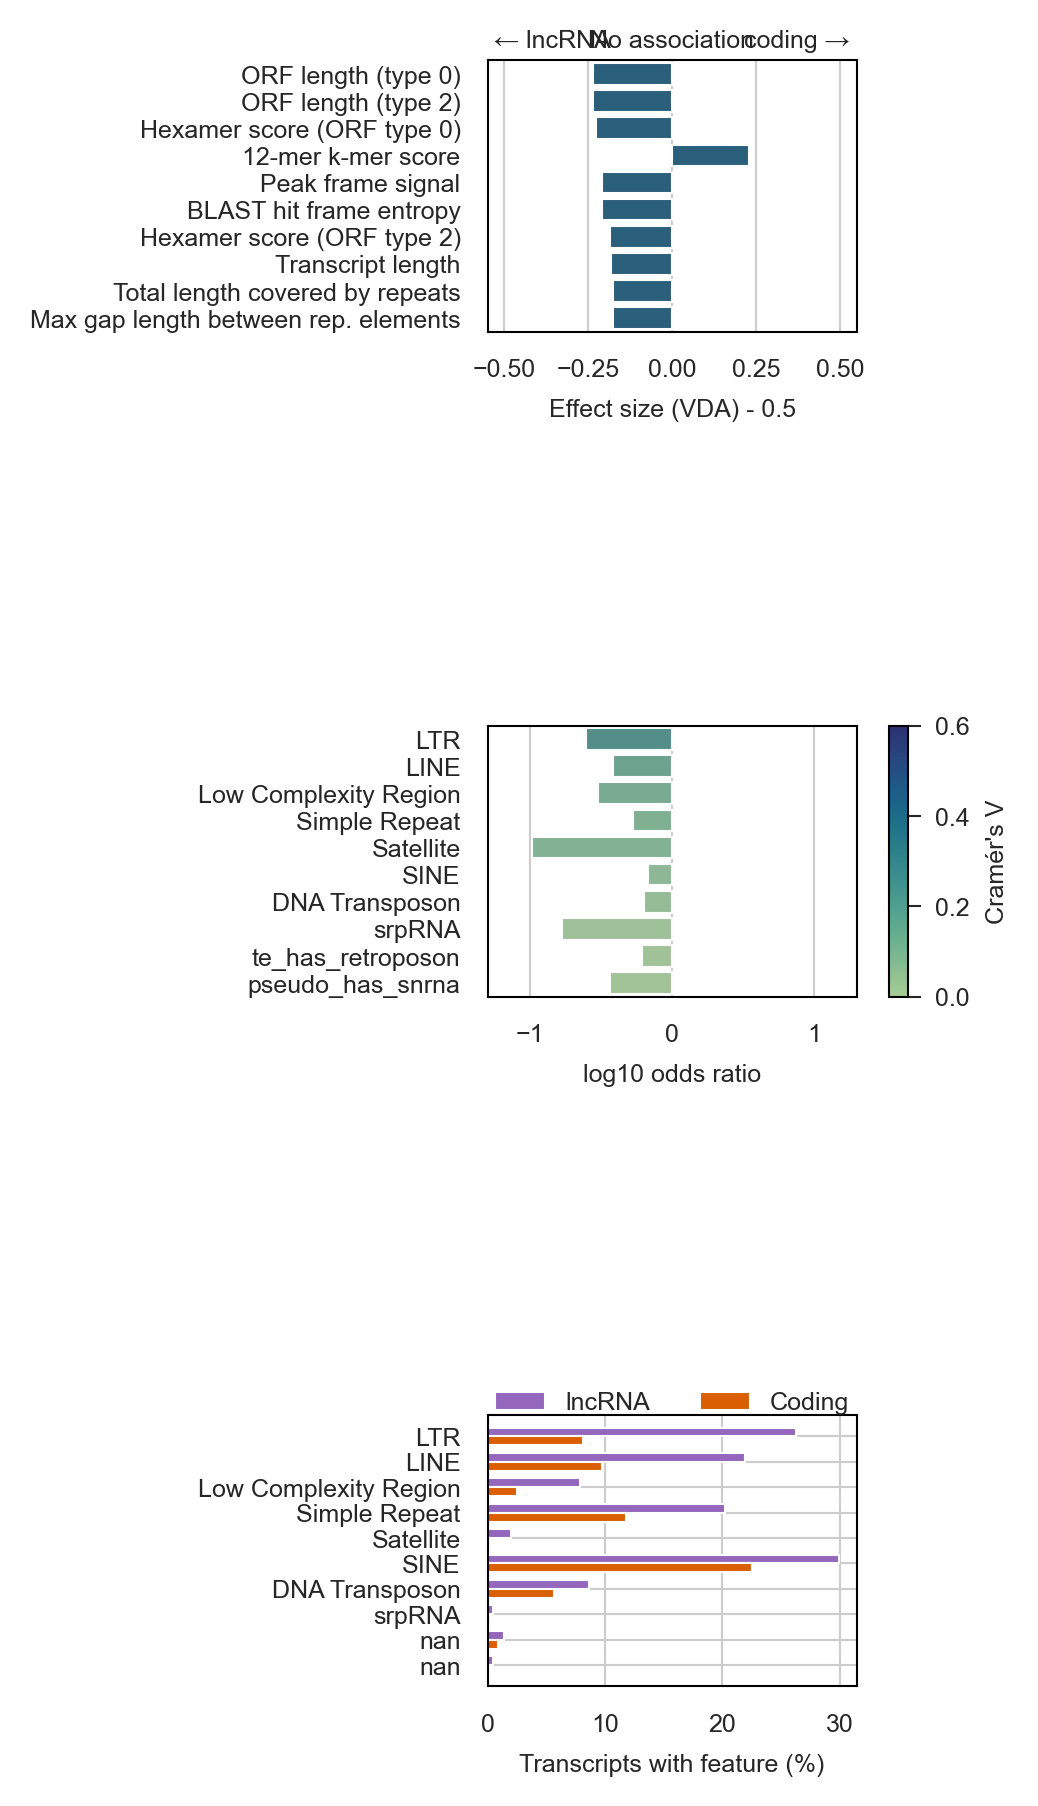

In [ ]:
mannu_he, chi2_he, combined_he = run_stat_tests(sc_he, cat_he, grp1_he, grp2_he)
clustered_he = build_clustered_mannu(combined_he, CLUSTER_FILE, MANN_TIDY_COLS)

# Feature frequencies for top categorical features
top10_cat_he = chi2_he.sort_values('cramers_v', ascending=False).head(10)
freq_rows_he = []
for feature in top10_cat_he.index:
    lnc_vals = cat_he.loc[grp1_he, feature]
    cod_vals = cat_he.loc[grp2_he, feature]
    freq_rows_he.append({'feature': feature,
                          'lncRNA': lnc_vals.sum() / len(lnc_vals) * 100,
                          'Coding': cod_vals.sum() / len(cod_vals) * 100})
freq_he = pd.DataFrame(freq_rows_he).set_index('feature')
freq_he['label'] = freq_he.index.map(FEATURE_LABEL_DICT)
freq_he = freq_he.loc[top10_cat_he.index]

plot_combined_stat_test(
    clustered_he, chi2_he, freq_he,
    label_dict=FEATURE_LABEL_DICT,
    save_path=FIGURE_DIR / "high_entropy_pc_v_lnc_statistical_tests_results.pdf",
    xlim_chi2=(-1.3, 1.3),
    chi2_annotation=('coding →', '← lncRNA'),
)


### Figure 5 – Low-Entropy PC vs lncRNA Feature Differences
*Source: `020_feature_stat_tests_correctness.fix.ipynb`, last plot*

In [ ]:
# ── Group: low-entropy transcripts (bottom 10 % H_pred), split by biotype ──
low_perc_th  = 0.1
low_th_le    = np.percentile(entropy_df['H_pred'], low_perc_th * 100)
low_mask_le  = entropy_df['H_pred'] <= low_th_le
low_df_le    = entropy_df[low_mask_le]

grp1_le = low_df_le[low_df_le["coding_class"] == 0].index   # lncRNA
grp2_le = low_df_le[low_df_le["coding_class"] == 1].index   # coding

sc_le  = remove_constant_features(full_feature_set[scalar_cols].loc[grp1_le.union(grp2_le)])
cat_le = remove_constant_features(full_feature_set[cat_cols].loc[grp1_le.union(grp2_le)])
print(f"Low-entropy group: {len(grp1_le)} lncRNA | {len(grp2_le)} PC")

Dataset: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']
Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
Low-entropy group: 1720 lncRNA | 9446 PC


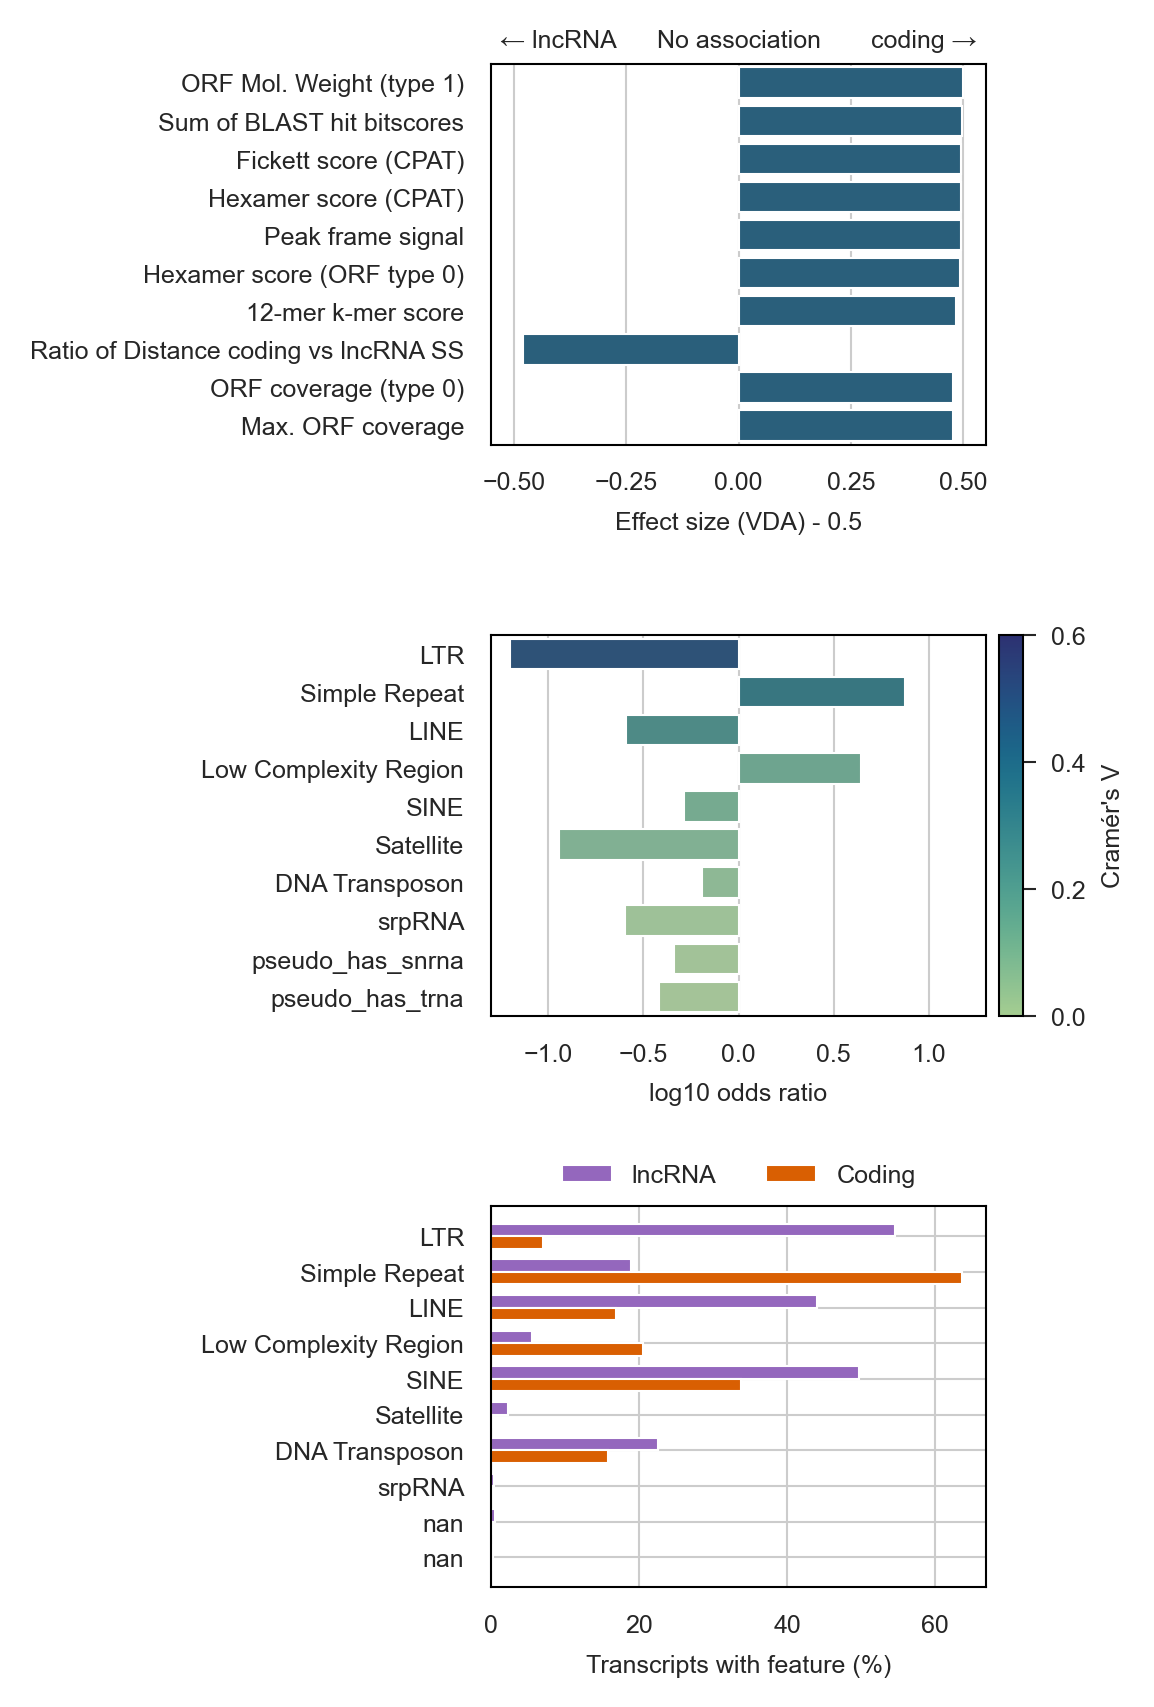

In [ ]:
mannu_le, chi2_le, combined_le = run_stat_tests(sc_le, cat_le, grp1_le, grp2_le)
clustered_le = build_clustered_mannu(combined_le, CLUSTER_FILE, MANN_TIDY_COLS)

top10_cat_le = chi2_le.sort_values('cramers_v', ascending=False).head(10)
freq_rows_le = []
for feature in top10_cat_le.index:
    lnc_vals = cat_le.loc[grp1_le, feature]
    cod_vals = cat_le.loc[grp2_le, feature]
    freq_rows_le.append({'feature': feature,
                          'lncRNA': lnc_vals.sum() / len(lnc_vals) * 100,
                          'Coding': cod_vals.sum() / len(cod_vals) * 100})
freq_le = pd.DataFrame(freq_rows_le).set_index('feature')
freq_le['label'] = freq_le.index.map(FEATURE_LABEL_DICT)
freq_le = freq_le.loc[top10_cat_le.index]

plot_combined_stat_test(
    clustered_le, chi2_le, freq_le,
    label_dict=FEATURE_LABEL_DICT,
    save_path=FIGURE_DIR / "low_entropy_pc_v_lnc_statistical_tests_results.pdf",
    xlim_chi2=(-1.3, 1.3),
    chi2_annotation=('coding →', '← lncRNA'),
)


### Figure 6 – Low vs High Entropy Feature Differences
*Source: `020_feature_stat_tests_pred_bald.fix.ipynb`, last plot*

In [ ]:
# ── Group: low entropy (bottom 10%) vs high entropy (top 10% H_pred + I_bald) ──
low_th_pb     = np.percentile(entropy_df['H_pred'], 10)
high_th_pb    = np.percentile(entropy_df['H_pred'], 90)
high_bald_pb  = np.percentile(entropy_df['I_bald'],  90)

low_mask_pb  = entropy_df['H_pred'] <= low_th_pb
high_mask_pb = (entropy_df['H_pred'] >= high_th_pb) & (entropy_df['I_bald'] >= high_bald_pb)

low_tx  = entropy_df[low_mask_pb].index
high_tx = entropy_df[high_mask_pb].index

sc_pb  = remove_constant_features(full_feature_set[scalar_cols].loc[low_tx.union(high_tx)])
cat_pb = remove_constant_features(full_feature_set[cat_cols].loc[low_tx.union(high_tx)])
print(f"Low entropy: {len(low_tx)} | High entropy: {len(high_tx)}")

Dataset: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']
Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
Low entropy: 11166 | High entropy: 3730


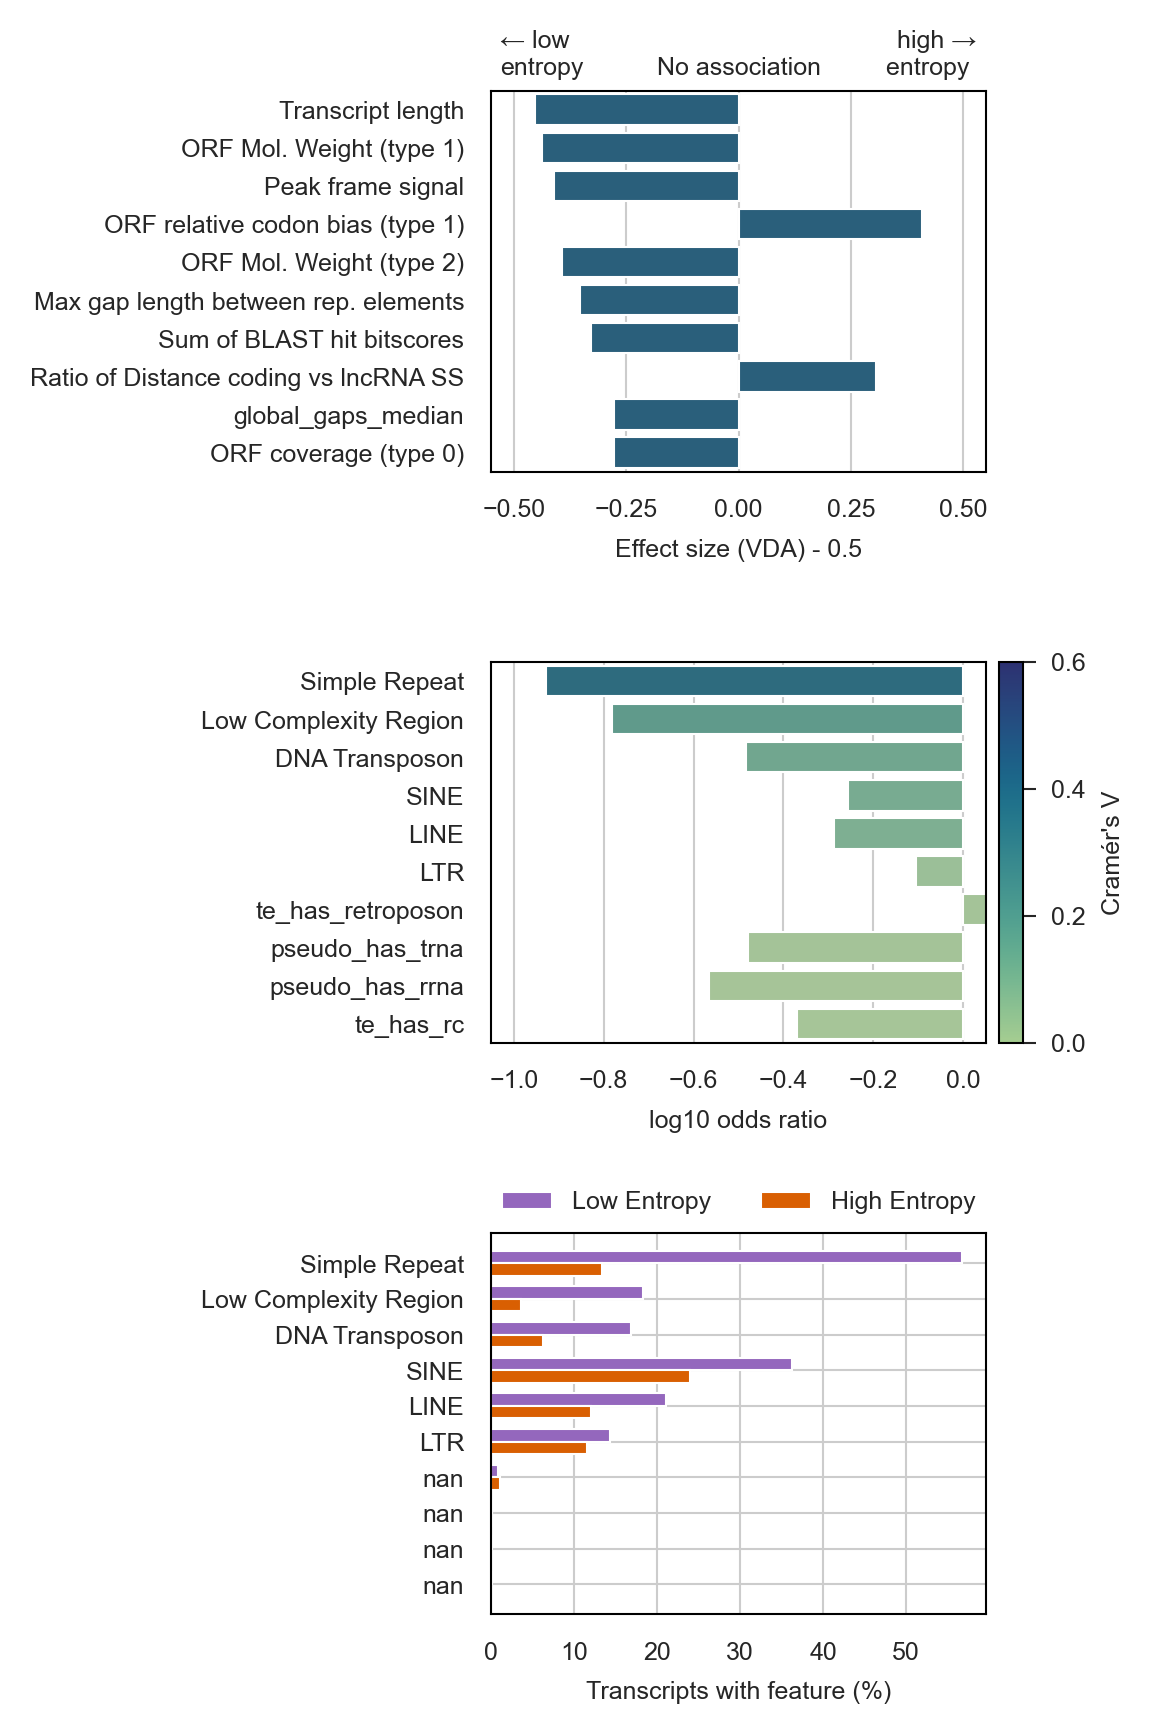

In [ ]:
mannu_pb, chi2_pb, combined_pb = run_stat_tests(sc_pb, cat_pb, low_tx, high_tx)
clustered_pb = build_clustered_mannu(combined_pb, CLUSTER_FILE, MANN_TIDY_COLS)

top10_cat_pb = chi2_pb.sort_values('cramers_v', ascending=False).head(10)
freq_rows_pb = []
for feature in top10_cat_pb.index:
    low_vals  = cat_pb.loc[low_tx.intersection(cat_pb.index), feature]
    high_vals = cat_pb.loc[high_tx.intersection(cat_pb.index), feature]
    freq_rows_pb.append({'feature': feature,
                          'Low Entropy':  low_vals.sum()  / len(low_vals)  * 100,
                          'High Entropy': high_vals.sum() / len(high_vals) * 100})
freq_pb = pd.DataFrame(freq_rows_pb).set_index('feature')
freq_pb['label'] = freq_pb.index.map(FEATURE_LABEL_DICT)
freq_pb = freq_pb.loc[top10_cat_pb.index]

plot_combined_stat_test(
    clustered_pb, chi2_pb, freq_pb,
    label_dict=FEATURE_LABEL_DICT,
    save_path=FIGURE_DIR / "combined_univariate_analysis_entropy.pdf",
    xlim_chi2=(-1.05, 0.05),
    chi2_annotation=('high →\nentropy ', '← low\nentropy'),
)


### Figure 7 – UpSet Plot (Full with Percentages)
*Source: `003_upset.ipynb`, cell 12 ('Full with percentages')*

In [ ]:
import upsetplot as upset
from upsetplot import from_indicators
from matplotlib.lines import Line2D

# Tool list and sorting by upset count
kept_tools = ["mrnn", "ss_lncDC", "rnasamba", "ss_lncfinder", "feelnc", "l_cpat", "plncpro", "lncrnabert"]
kept_tools_real = kept_tools + ["real"]

test_df = labels_file.copy()

full_upset_raw = from_indicators(kept_tools_real, data=test_df)
group_count = (full_upset_raw.groupby(level=list(range(len(full_upset_raw.index.names))))
                             .size().reset_index(name='count')
                             .sort_values(by='count', ascending=False))
cols = [c for c in group_count.columns if c not in ["real", "count"]]
counts = [group_count[group_count[c] == True]["count"].sum() for c in cols]
sorted_tools = pd.DataFrame({"tool": cols, "count": counts}).sort_values("count", ascending=False)["tool"].tolist()

full_upset = full_upset_raw.reorder_levels(["real"] + sorted_tools)
print(f"Sorted tools: {sorted_tools}")

Sorted tools: ['l_cpat', 'plncpro', 'lncrnabert', 'mrnn', 'feelnc', 'rnasamba', 'ss_lncfinder', 'ss_lncDC']


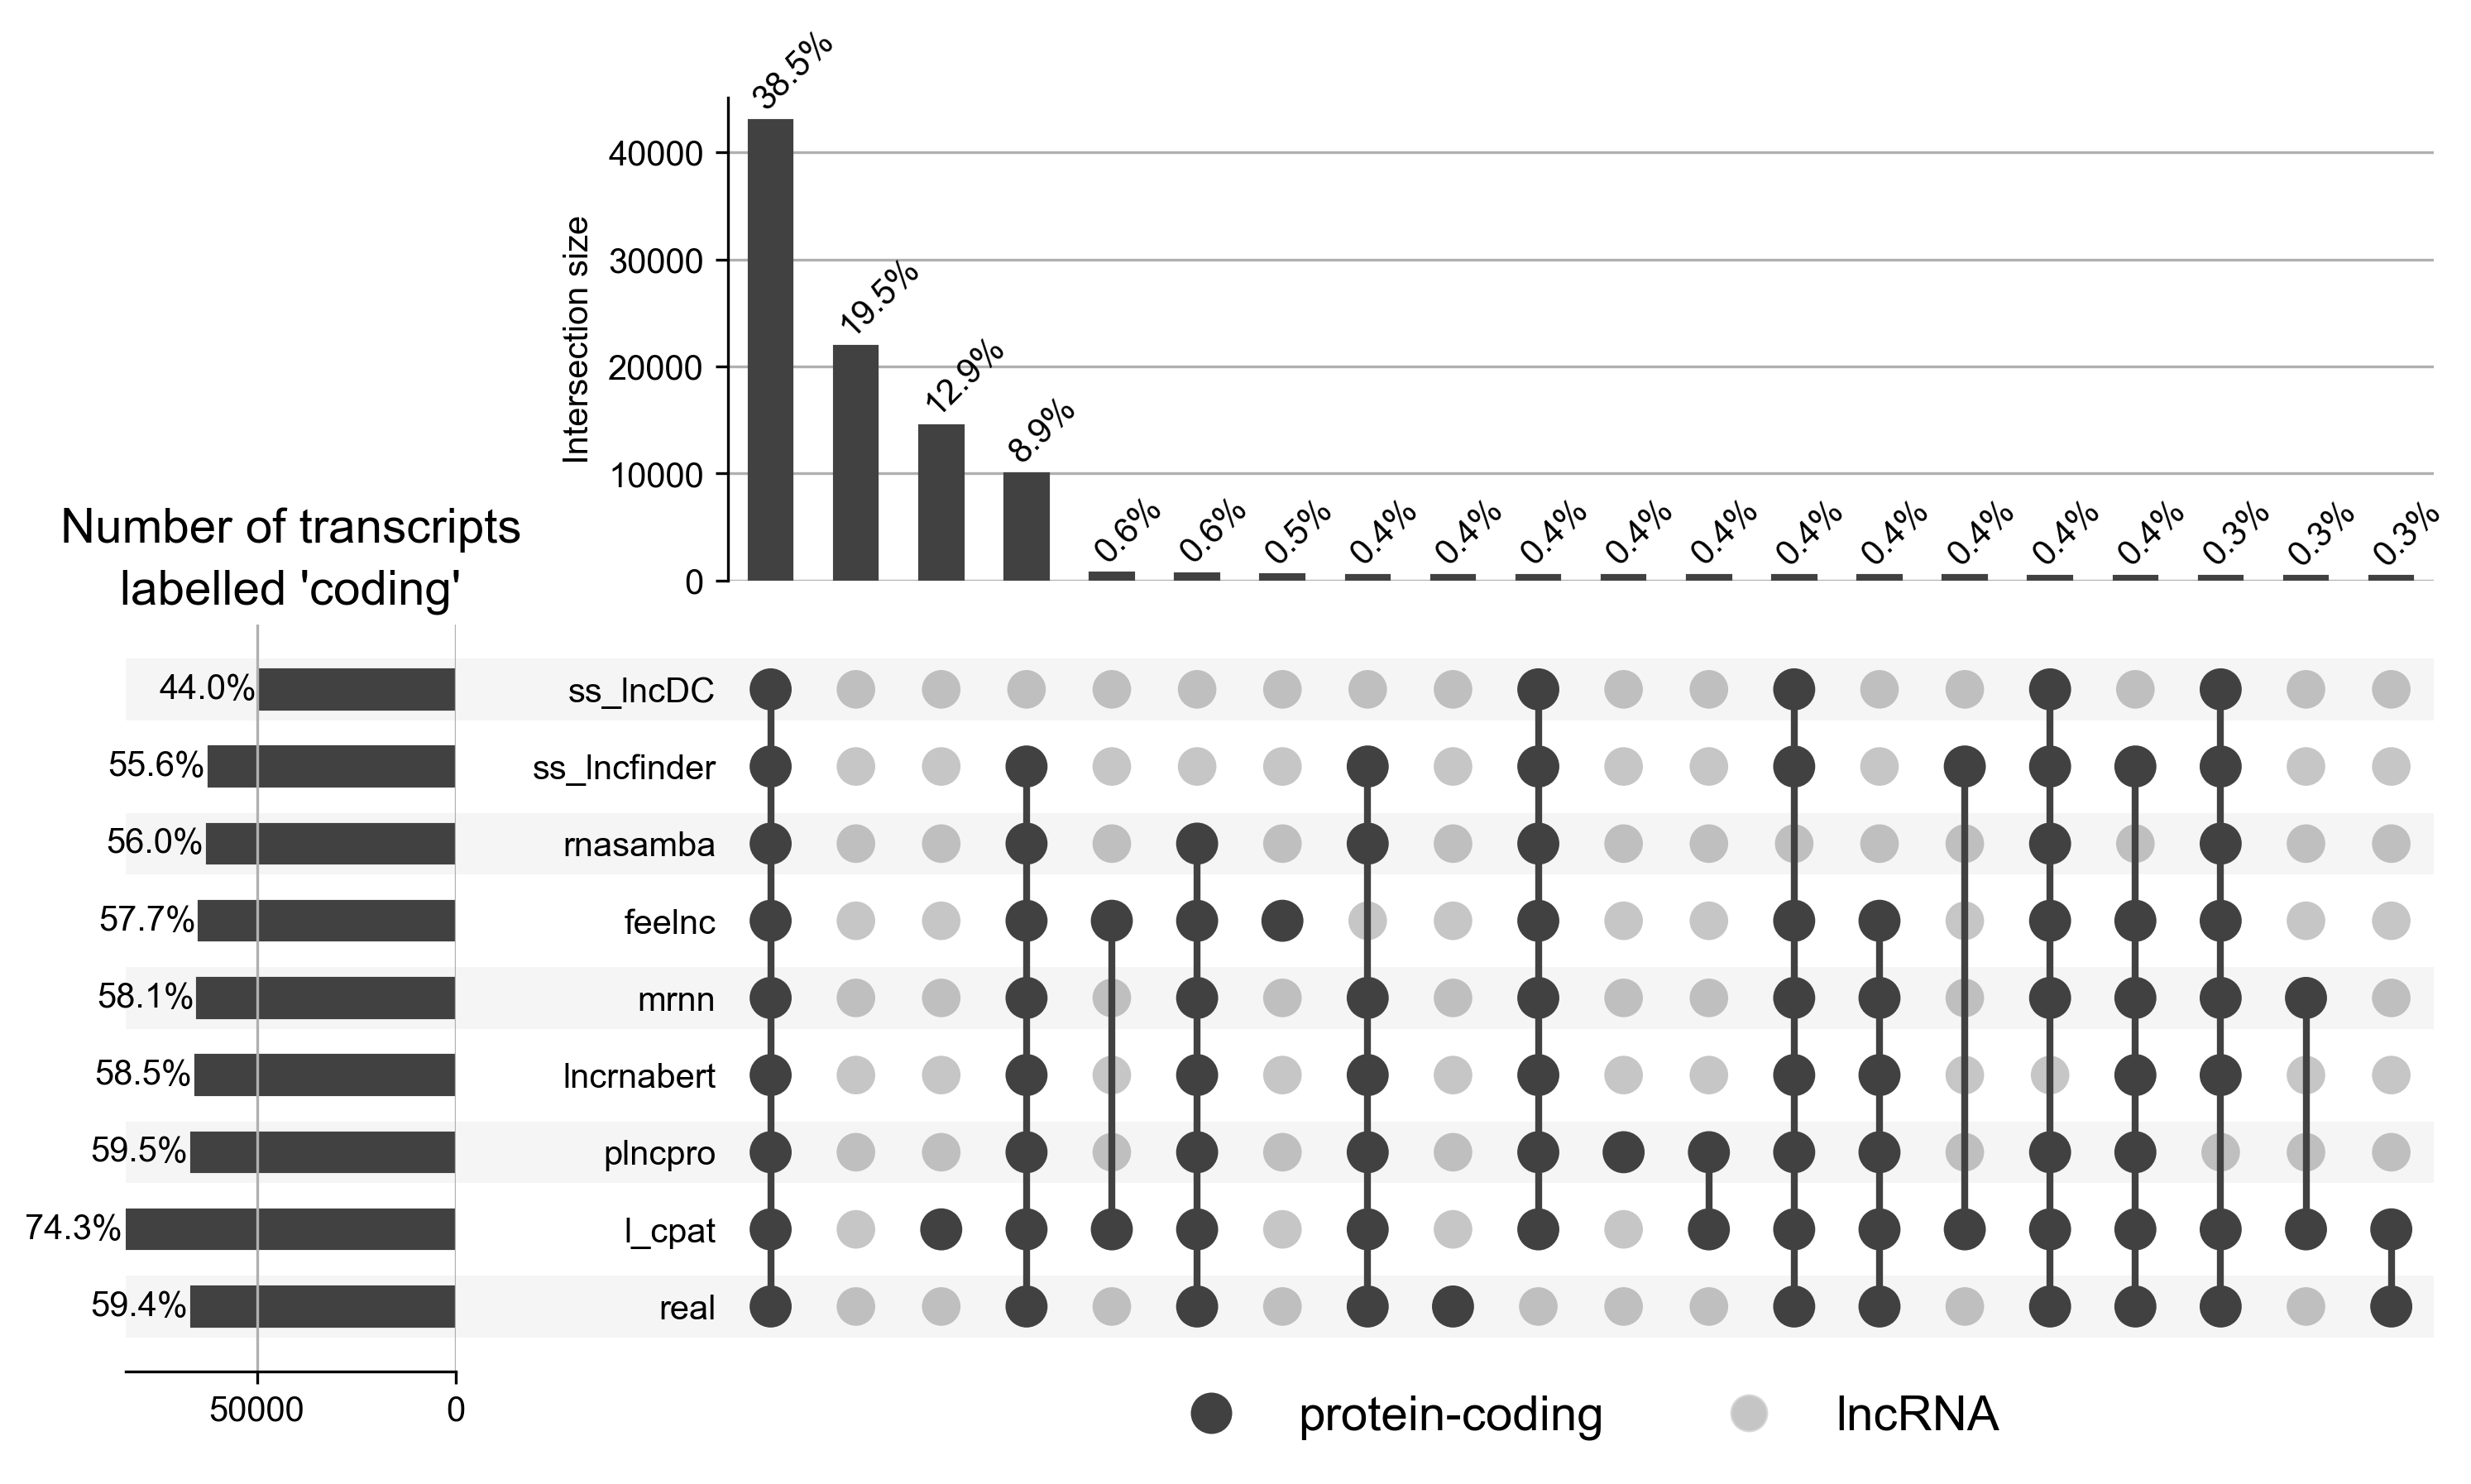

In [ ]:
# ── Plot: UpSet full with percentages ───────────────────────────────────────
up = upset.UpSet(full_upset,
                 show_percentages="{:.1%}",
                 totals_plot_elements=4,
                 sort_by="cardinality",
                 sort_categories_by="input",
                 max_subset_rank=20,
                 facecolor="#414141",
                 other_dots_color=0.3,
                 element_size=32)

fig = plt.figure(figsize=(6, 6), dpi=300)
axes_dict = up.plot(fig=fig)

# Matrix: legend for dot colours
matrix_ax = axes_dict['matrix']
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#414141',
           markersize=13, label='protein-coding'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#414141',
           markersize=11, alpha=0.3, label='lncRNA')
]
matrix_ax.legend(handles=legend_elements, loc='lower center', fontsize=14,
                 frameon=False, ncol=2, bbox_to_anchor=(0.5, -0.15))

# Totals
totals_ax = axes_dict["totals"]
totals_ax.set_title("Number of transcripts\nlabelled 'coding'", fontsize=14, linespacing=1.5)

# Intersection: rotate count labels
intersections_ax = axes_dict['intersections']
for text_obj in intersections_ax.texts:
    text_obj.set_rotation(45)
    text_obj.set_rotation_mode("anchor")
    text_obj.set_ha('left')

plt.savefig(FIGURE_DIR / "main_upset.pdf", bbox_inches="tight", format="pdf")
plt.show()

### Figure 8 – t-SNE Three Panels
*Source: `022_cv_embeddings.ipynb`, last plot*

In [ ]:
from utils.entropy import load_dataset as load_dataset_entropy, bootstrap_bin_accuracy
from utils.embeddings import (
 EmbeddingPipeline
)
from utils.plotting import COLORS

EMBEDDING_DIR = RESULTS_DIR / 'features' / 'embeddings'
EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
SUBSET_ID = "all"
DOT_SIZE  = 0.4
DOT_ALPHA = 0.3

DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=40)
           2	RESUME(arg=0, lineno=40)
           4	LOAD_FAST(arg=0, lineno=53)
           6	LOAD_CONST(arg=1, lineno=53)
           8	BINARY_SUBSCR(arg=None, lineno=53)
          12	LOAD_CONST(arg=2, lineno=53)
          14	BINARY_OP(arg=1, lineno=53)
          18	LOAD_CONST(arg=3, lineno=53)
          20	BINARY_OP(arg=3, lineno=53)
          24	LOAD_CONST(arg=4, lineno=53)
          26	BINARY_OP(arg=1, lineno=53)
          30	LOAD_FAST(arg=0, lineno=54)
          32	LOAD_CONST(arg=1, lineno=54)
          34	BINARY_SUBSCR(arg=None, lineno=54)
          38	LOAD_CONST(arg=5, lineno=54)
          40	BINARY_OP(arg=3, lineno=54)
          44	LOAD_CONST(arg=4, lineno=54)
          46	BINARY_OP(arg=1, lineno=54)
          50	LOAD_FAST(arg=0, lineno=54)
          52	LOAD_CONST(arg=1, lineno=54)
          54	BINARY_SUBSCR(arg=None, lineno=54)
          58	BINARY_OP(arg=12, lineno=54)
          62	LOAD_CONST(arg=6, li

In [ ]:
# ── Load and scale features for embedding ───────────────────────────────────
dataset_emb  = load_dataset_entropy(DSET)
feats_emb    = filter_feature_columns(dataset_emb['features'])
feats_emb_df = dataset_emb['features'][feats_emb]

numeric_cols_emb = feats_emb_df.select_dtypes(include=[np.number]).columns
constant_emb     = feats_emb_df[numeric_cols_emb].nunique()
constant_emb     = constant_emb[constant_emb <= 1].index.tolist()
selected_emb_df  = feats_emb_df[numeric_cols_emb].drop(columns=constant_emb)

scaled_vals    = custom_feature_scaling(selected_emb_df)
scaled_emb_df  = pd.DataFrame(scaled_vals, index=selected_emb_df.index, columns=selected_emb_df.columns)

print(f"Features for t-SNE: {scaled_emb_df.shape[1]} | Transcripts: {len(scaled_emb_df)}")

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_lncDC', 'Hexamer_score_ORF_T2_lncDC', 'Hexamer_score_ORF_T3_lncDC', 'RCB_T0_lncDC', 'RCB_T1_lncDC', 'ORF_T0_PI_lncDC', 'ORF_T0_MW_lncDC', 'ORF_T0_aromaticity

In [ ]:
# ── Load t-SNE embedding ─────────────────────────────────────────
pipeline_emb = EmbeddingPipeline(embedding_dir=EMBEDDING_DIR, subset_id=SUBSET_ID, resource_guard=None)
tsne_embedding, tsne_metadata = pipeline_emb.compute_or_load_embedding(
    scaled_emb_df, scaled_emb_df.index,
    method="tsne", perplexity=30, n_iter=1000, random_state=42, force_recompute=False
)

Loading cached embedding from /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/embeddings/cache/tsne_p30_i1000_all.npz


In [ ]:
# ── Prepare plot dataframe ───────────────────────────────────────────────────
labels_emb = dataset_emb['labels']

plot_df = pd.DataFrame(tsne_embedding, index=scaled_emb_df.index, columns=["tsne_1", "tsne_2"])
plot_df["coding_class"] = labels_emb.loc[plot_df.index, "coding_class"].map({1: "coding", 0: "lncRNA"})
plot_df = plot_df.join(entropy_df[["H_pred", "I_bald"]], how="left")

# Compute entropy_class fresh on plot_df (entropy_df may already have "other" from Figure 3)
low_th_e    = np.percentile(entropy_df["H_pred"], 10)
high_th_e   = np.percentile(entropy_df["H_pred"], 90)
high_bald_e = np.percentile(entropy_df["I_bald"],  90)
plot_df["entropy_class"] = "medium"
plot_df.loc[plot_df["H_pred"] < low_th_e, "entropy_class"] = "low"
plot_df.loc[(plot_df["H_pred"] > high_th_e) & (plot_df["I_bald"] > high_bald_e), "entropy_class"] = "high"

plot_df = plot_df.sample(frac=1, random_state=42)


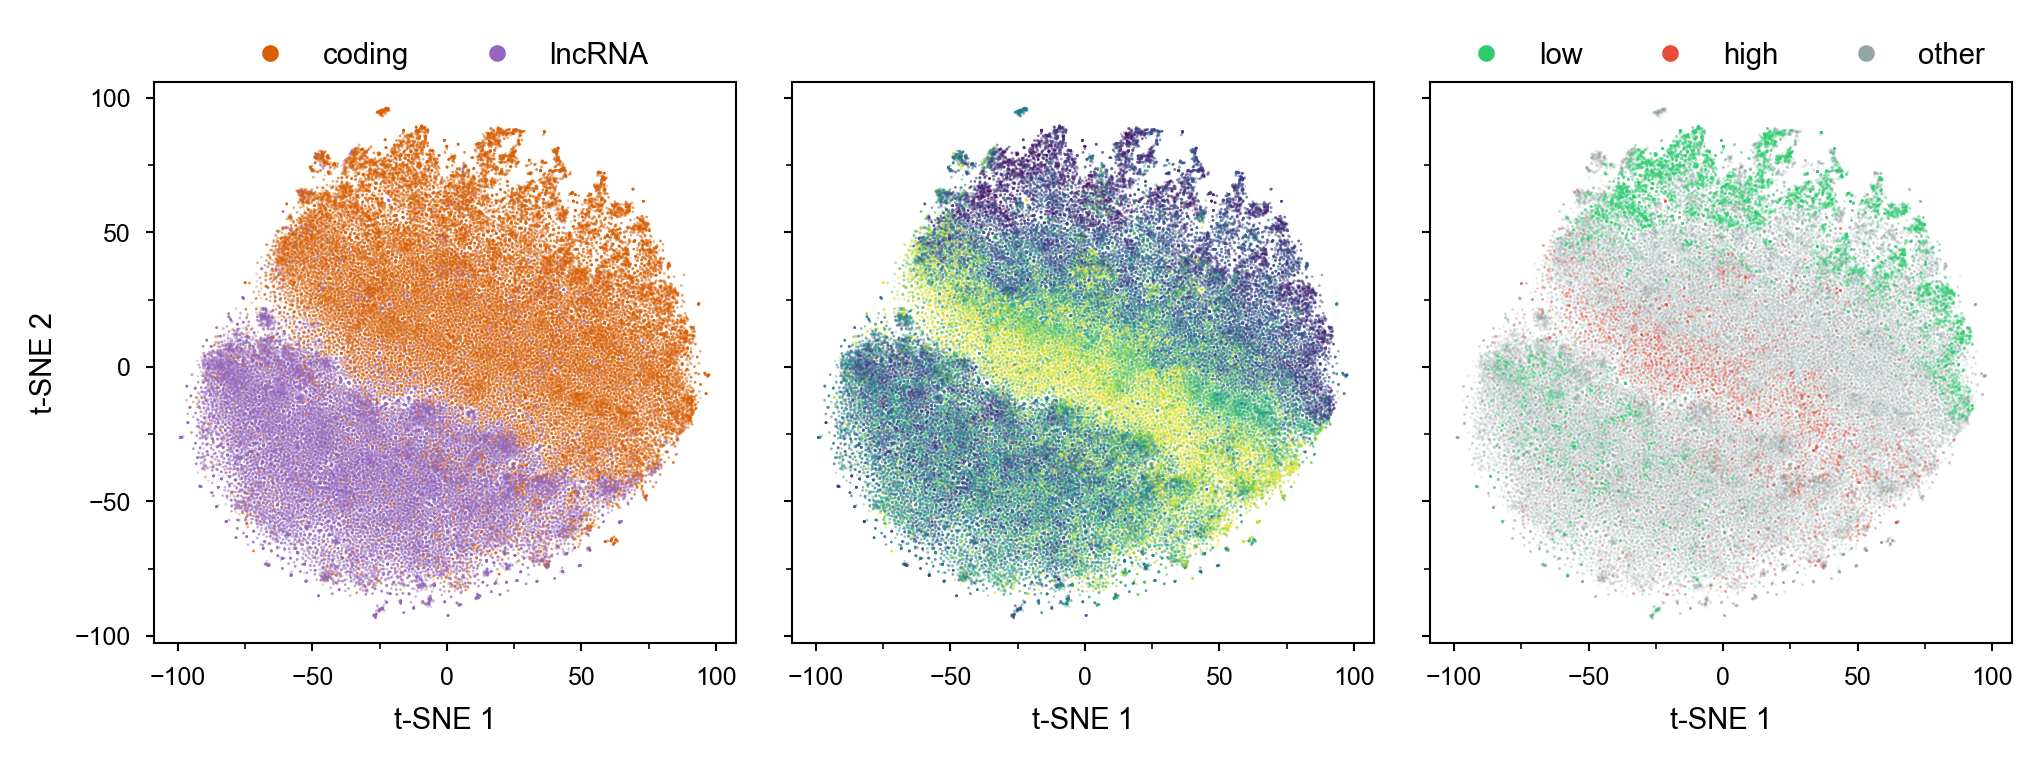

In [ ]:
# ── Plot: three-panel t-SNE ──────────────────────────────────────────────────
fig_h, fig_w = 6, 17  # cm
fig, axes = plt.subplots(1, 3, figsize=(fig_w/2.54, fig_h/2.54),
                         sharey=True, constrained_layout=True)

# Panel 1: Coding class
sns.scatterplot(data=plot_df, x="tsne_1", y="tsne_2",
                hue="coding_class",
                palette={"coding": COLORS["pc"], "lncRNA": COLORS["lnc"]},
                s=DOT_SIZE, alpha=DOT_ALPHA, linewidth=0,
                legend=False, ax=axes[0], rasterized=True)
legend_handles_cls = [
    plt.Line2D([0], [0], marker='o', color='w', label='coding',  markerfacecolor=COLORS["pc"],  markersize=5),
    plt.Line2D([0], [0], marker='o', color='w', label='lncRNA',  markerfacecolor=COLORS["lnc"], markersize=5),
]
axes[0].legend(handles=legend_handles_cls, title="", loc="upper center",
               bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False, fontsize=7)

# Panel 2: Predictive entropy (continuous colour)
axes[1].scatter(plot_df["tsne_1"], plot_df["tsne_2"],
                c=plot_df["H_pred"], cmap="viridis",
                s=DOT_SIZE, alpha=DOT_ALPHA, linewidths=0, rasterized=True)

# Panel 3: Entropy groups
m = plot_df["entropy_class"] == "medium"
h = plot_df["entropy_class"] == "high"
l = plot_df["entropy_class"] == "low"
axes[2].scatter(plot_df.loc[m, "tsne_1"], plot_df.loc[m, "tsne_2"],
                c="#95a5a6", s=DOT_SIZE, alpha=DOT_ALPHA*0.4, linewidths=0, rasterized=True)
axes[2].scatter(plot_df.loc[h, "tsne_1"], plot_df.loc[h, "tsne_2"],
                c="#e74c3c", s=DOT_SIZE, alpha=DOT_ALPHA,     linewidths=0, rasterized=True)
axes[2].scatter(plot_df.loc[l, "tsne_1"], plot_df.loc[l, "tsne_2"],
                c="#2ecc71", s=DOT_SIZE, alpha=DOT_ALPHA,     linewidths=0, rasterized=True)
legend_handles_ent = [
    plt.Line2D([0], [0], marker='o', color='w', label='low',   markerfacecolor="#2ecc71", markersize=5),
    plt.Line2D([0], [0], marker='o', color='w', label='high',  markerfacecolor="#e74c3c", markersize=5),
    plt.Line2D([0], [0], marker='o', color='w', label='other', markerfacecolor="#95a5a6", markersize=5),
]
axes[2].legend(handles=legend_handles_ent, title="", loc="upper center",
               bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=7)

# Shared styling
for ax in axes:
    ax.set_xlabel("t-SNE 1", fontsize=7)
    ax.set_aspect("equal")
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    ax.yaxis.set_major_locator(plt.MultipleLocator(50))
    ax.tick_params(width=0.5, length=2, labelsize=6)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(25))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(25))
    ax.tick_params(axis="both", which="minor", labelbottom=False, labelleft=False, length=1.5, width=0.4)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
axes[0].set_ylabel("t-SNE 2", fontsize=7)
fig.get_layout_engine().set(wspace=0.07)

fig.set_dpi(300)
plt.savefig(FIGURE_DIR / "tsne_three_panels.pdf", dpi=300, format="pdf")
plt.show()

### Figure 9 – SHAP Feature Importance
*Source: `028_load_and_plot_shap.ipynb`*

In [ ]:
# ── SHAP configuration ────────────────────────────────────────────────────────
SHAP_DIR = BASE / "results" / DSET / "features/shap_clustered"
TOP_N    = 20

assert SHAP_DIR.exists(), f"SHAP_DIR not found: {SHAP_DIR}"

# ── Load aggregated SHAP CSVs ─────────────────────────────────────────────────
shap_agg          = pd.read_csv(SHAP_DIR / "shap_aggregated.csv", index_col=0)
per_fold_mean_abs = pd.read_csv(SHAP_DIR / "shap_per_fold_mean_abs.csv", index_col=0)
combined_preds    = pd.read_csv(SHAP_DIR / "all_predictions.csv", index_col=0)
perf_df           = pd.read_csv(SHAP_DIR / "performance_summary.csv", index_col=0)

print(f"shap_agg          : {shap_agg.shape}")
print(f"per_fold_mean_abs : {per_fold_mean_abs.shape}")
print(f"combined_preds    : {combined_preds.shape}")

# ── Load per-fold artefacts ───────────────────────────────────────────────────
def load_fold_artefacts(input_dir, n_folds=5):
    fold_data = {}
    for fold_i in range(1, n_folds + 1):
        fold_dir = input_dir / f"fold{fold_i}"
        required = ["shap_values.csv", "X_test.csv", "y_pred.csv", "base_val.txt"]
        if not all((fold_dir / f).exists() for f in required):
            print(f"WARNING: fold {fold_i} missing — skipping")
            continue
        fold_data[fold_i] = dict(
            shap_df  = pd.read_csv(fold_dir / "shap_values.csv", index_col=0),
            X_test   = pd.read_csv(fold_dir / "X_test.csv", index_col=0),
            y_pred   = pd.read_csv(fold_dir / "y_pred.csv", index_col=0),
            base_val = float((fold_dir / "base_val.txt").read_text().strip()),
        )
    return fold_data

fold_data = load_fold_artefacts(SHAP_DIR)
print(f"Loaded {len(fold_data)} folds: {sorted(fold_data.keys())}")


shap_agg          : (179, 3)
per_fold_mean_abs : (5, 179)
combined_preds    : (111652, 5)
Loaded 5 folds: [1, 2, 3, 4, 5]


#### Plot 9a – Feature importance (mean |SHAP|)
*Source: cell 12*

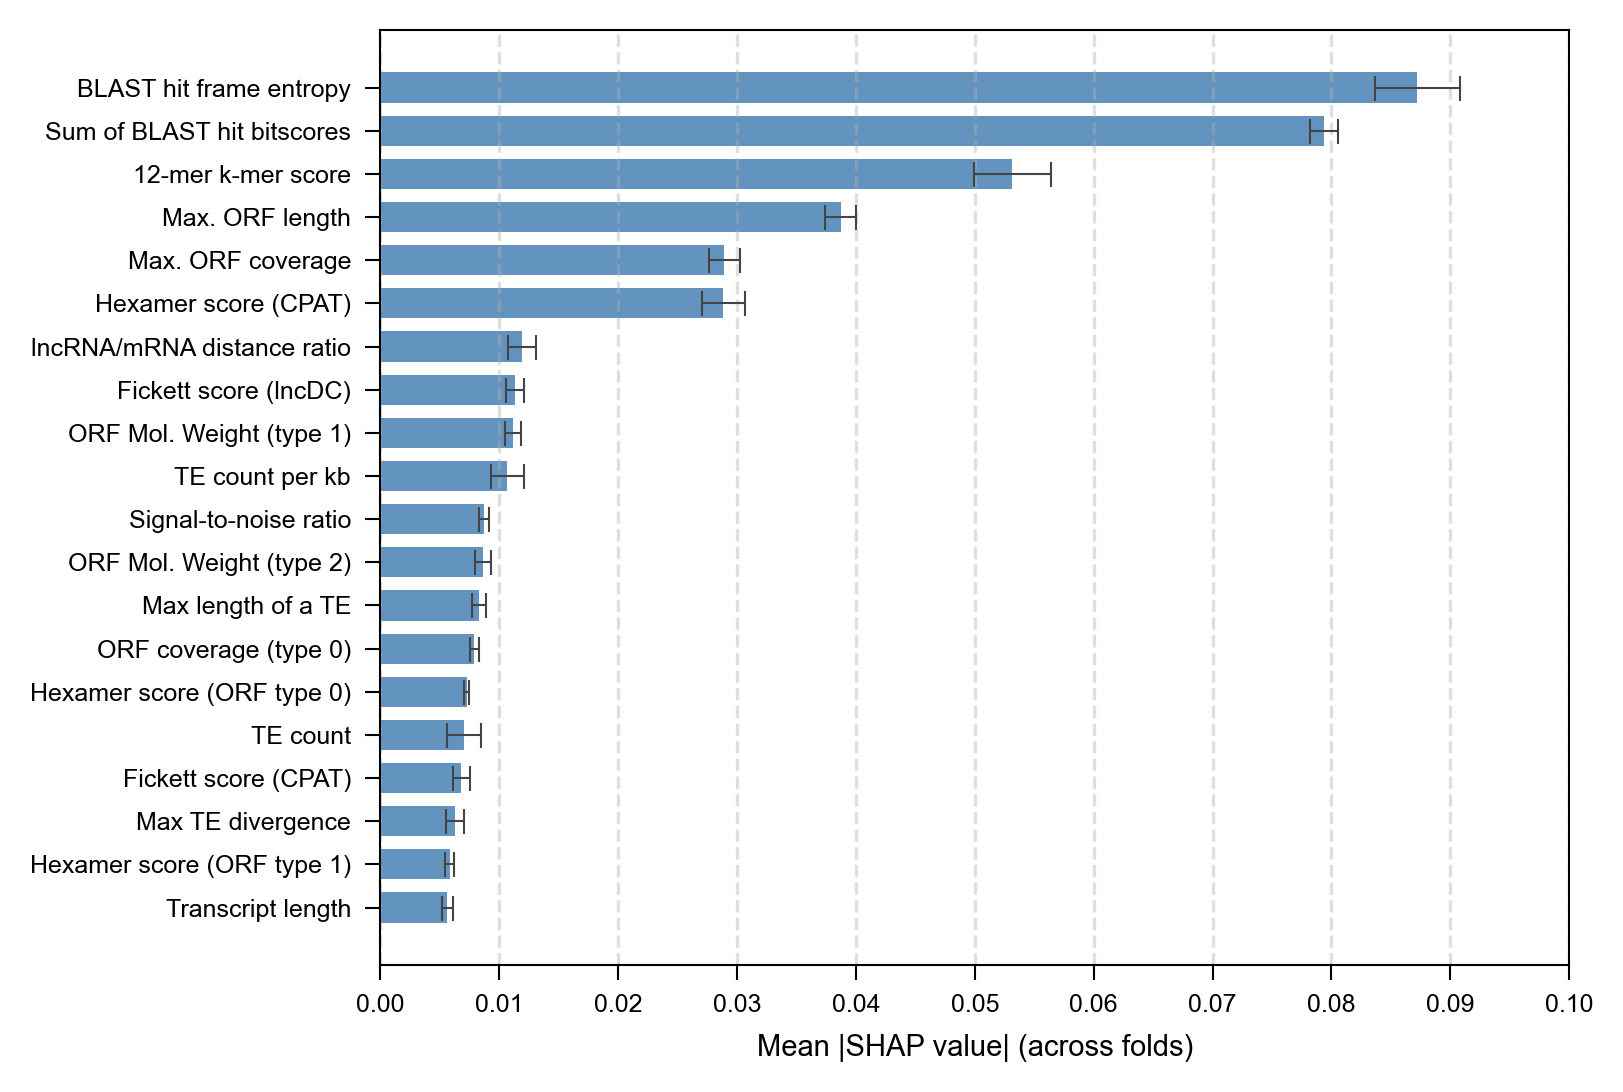

In [ ]:
import matplotlib.ticker as mticker

top = shap_agg.head(TOP_N).iloc[::-1].copy()
top["label"] = top.index.map(lambda x: FEATURE_LABEL_DICT.get(x, x))

plt.rcParams["lines.linewidth"]    = 0.5
plt.rcParams["xtick.major.width"]  = 0.5
plt.rcParams["ytick.major.width"]  = 0.5
plt.rcParams["axes.linewidth"]     = 0.5

w_cm = 14
h_cm = TOP_N * 0.4 + 1.5

fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54), dpi=300)
ax.barh(
    top["label"], top["mean_abs_shap"],
    xerr=top["std_abs_shap"],
    color="steelblue", ecolor="#444", alpha=0.85, height=0.7,
    error_kw={"elinewidth": 0.5, "capthick": 0.5, "capsize": 3},
)
ax.set_xlabel("Mean |SHAP value| (across folds)", fontsize=7)
ax.tick_params(axis="y", labelsize=6)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="x", linestyle="--", alpha=0.4)

max_x = (top["mean_abs_shap"] + top["std_abs_shap"]).max()
xmax  = np.ceil(max_x / 0.01) * 0.01
ax.set_xlim(0, xmax)
ax.set_xticks(np.arange(0, xmax + 0.01, 0.01))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.01))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.tick_params(axis="x", labelsize=6)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_importance_mean_std.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


#### Plot 9b – Cumulative SHAP importance
*Source: cell 13*

1-SE rule: select 178 features (100.00% importance)


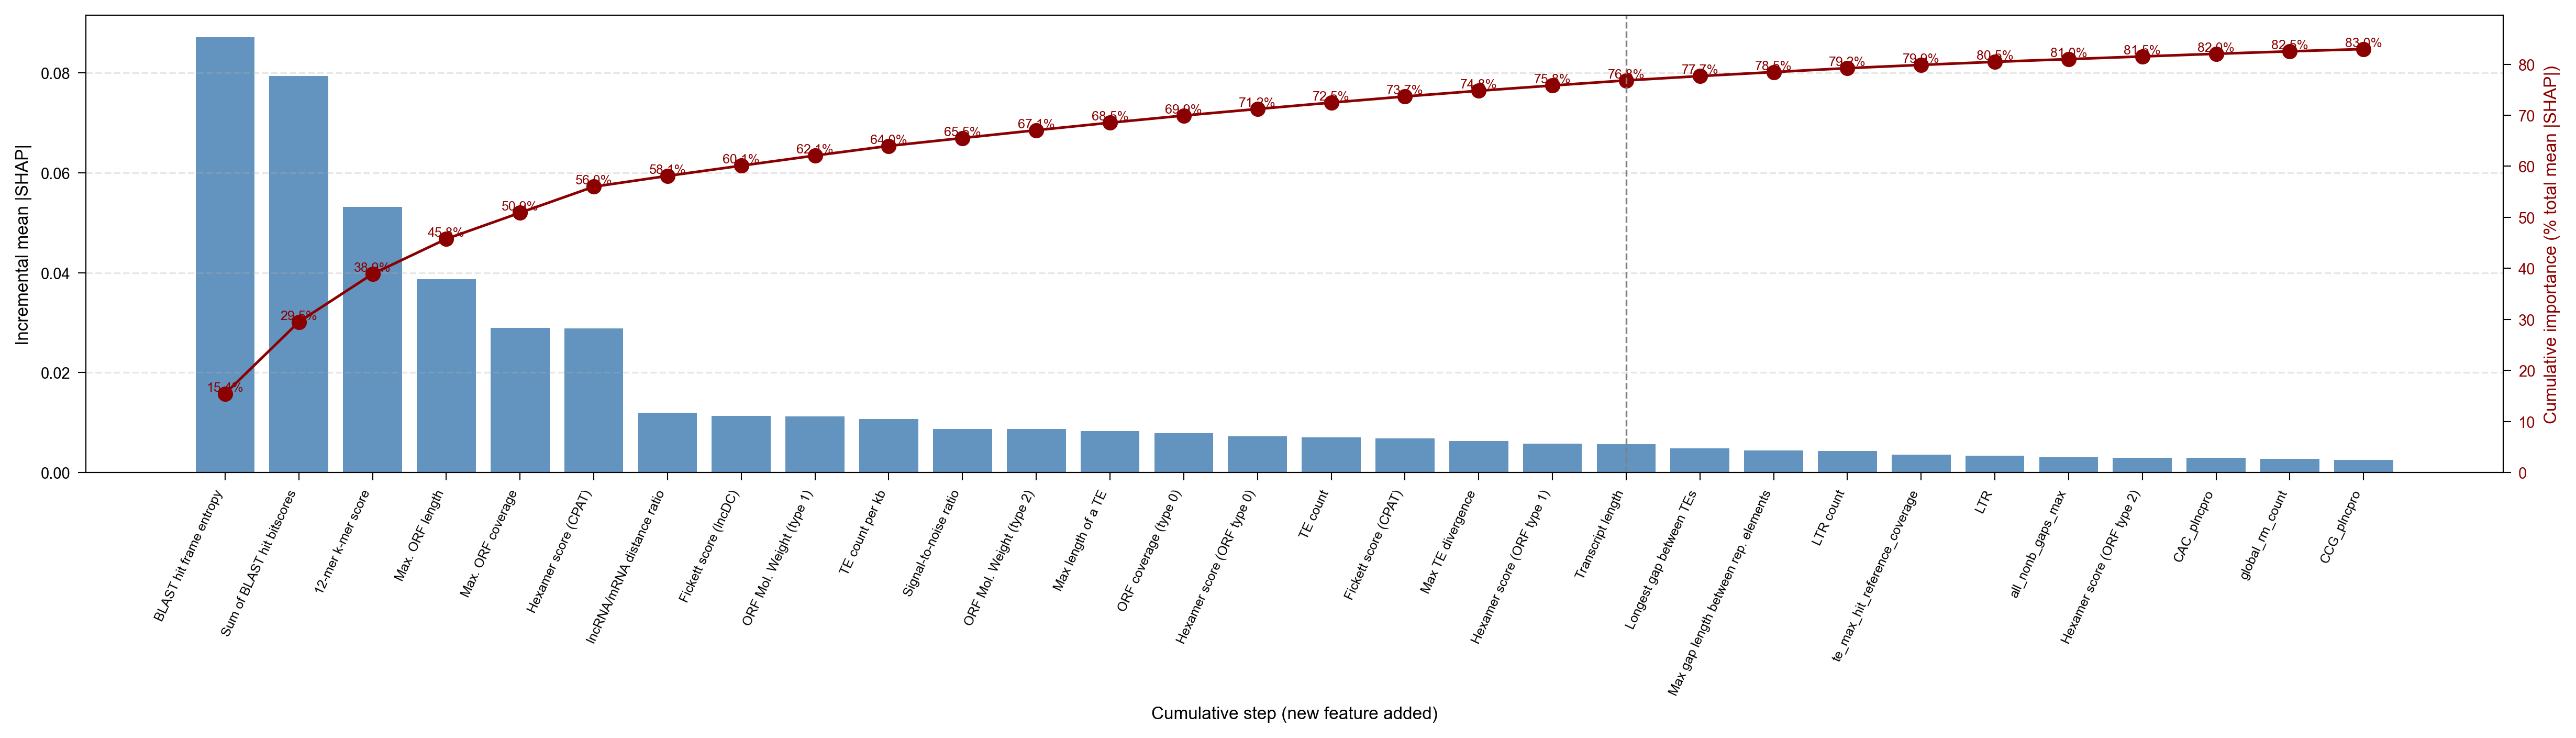

In [ ]:
cum_imp = (
    shap_agg["mean_abs_shap"]
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="mean_abs_shap")
)
cum_imp["feature_label"] = cum_imp["feature"].map(lambda f: FEATURE_LABEL_DICT.get(f, f))
cum_imp["step"]          = np.arange(1, len(cum_imp) + 1)
cum_imp["cum_abs_shap"]  = cum_imp["mean_abs_shap"].cumsum()
cum_imp["cum_pct_total"] = 100 * cum_imp["cum_abs_shap"] / cum_imp["mean_abs_shap"].sum()

ordered_features = [f for f in cum_imp["feature"] if f in per_fold_mean_abs.columns]
fold_curves = []
for _, row in per_fold_mean_abs[ordered_features].iterrows():
    vals  = row.to_numpy(dtype=float)
    total = vals.sum()
    if total > 0:
        fold_curves.append(np.cumsum(vals) / total * 100.0)
fold_curves = np.vstack(fold_curves)
n_cv        = fold_curves.shape[0]
mean_curve  = fold_curves.mean(axis=0)
se_curve    = fold_curves.std(axis=0, ddof=1) / np.sqrt(n_cv) if n_cv > 1 else np.zeros_like(mean_curve)

best_idx          = int(np.nanargmax(mean_curve))
ONE_SE_THRESHOLD  = mean_curve[best_idx] - se_curve[best_idx]
ONE_SE_STEP       = int(np.argmax(mean_curve >= ONE_SE_THRESHOLD) + 1)
print(f"1-SE rule: select {ONE_SE_STEP} features ({mean_curve[best_idx]:.2f}% importance)")

N_STEPS = min(TOP_N + 10, len(cum_imp))
sub = cum_imp.head(N_STEPS).copy()

fig, ax1 = plt.subplots(figsize=(max(9, N_STEPS * 0.55), 4.8), dpi=300)
ax1.bar(sub["step"], sub["mean_abs_shap"], color="steelblue", alpha=0.85)
ax1.set_xlabel("Cumulative step (new feature added)", fontsize=8)
ax1.set_ylabel("Incremental mean |SHAP|", fontsize=8)
ax1.set_xticks(sub["step"])
ax1.set_xticklabels(sub["feature_label"], rotation=65, ha="right", fontsize=6)
ax1.tick_params(axis="y", labelsize=7)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(sub["step"], sub["cum_pct_total"], color="darkred", marker="o", lw=1.2)
ax2.set_ylabel("Cumulative importance (% total mean |SHAP|)", color="darkred", fontsize=8)
ax2.tick_params(axis="y", labelcolor="darkred", labelsize=7)
ax2.set_ylim(0, min(100, sub["cum_pct_total"].max() * 1.08))
ax2.axvline(x=TOP_N, color="gray", linestyle="--", lw=0.8)
for x, y in zip(sub["step"], sub["cum_pct_total"]):
    ax2.text(x, y, f"{y:.1f}%", fontsize=6, color="darkred", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / f"shap_cumulative_importance_top{N_STEPS}.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


#### Plot 9c – Per-fold mean |SHAP| heatmap
*Source: cell 15*

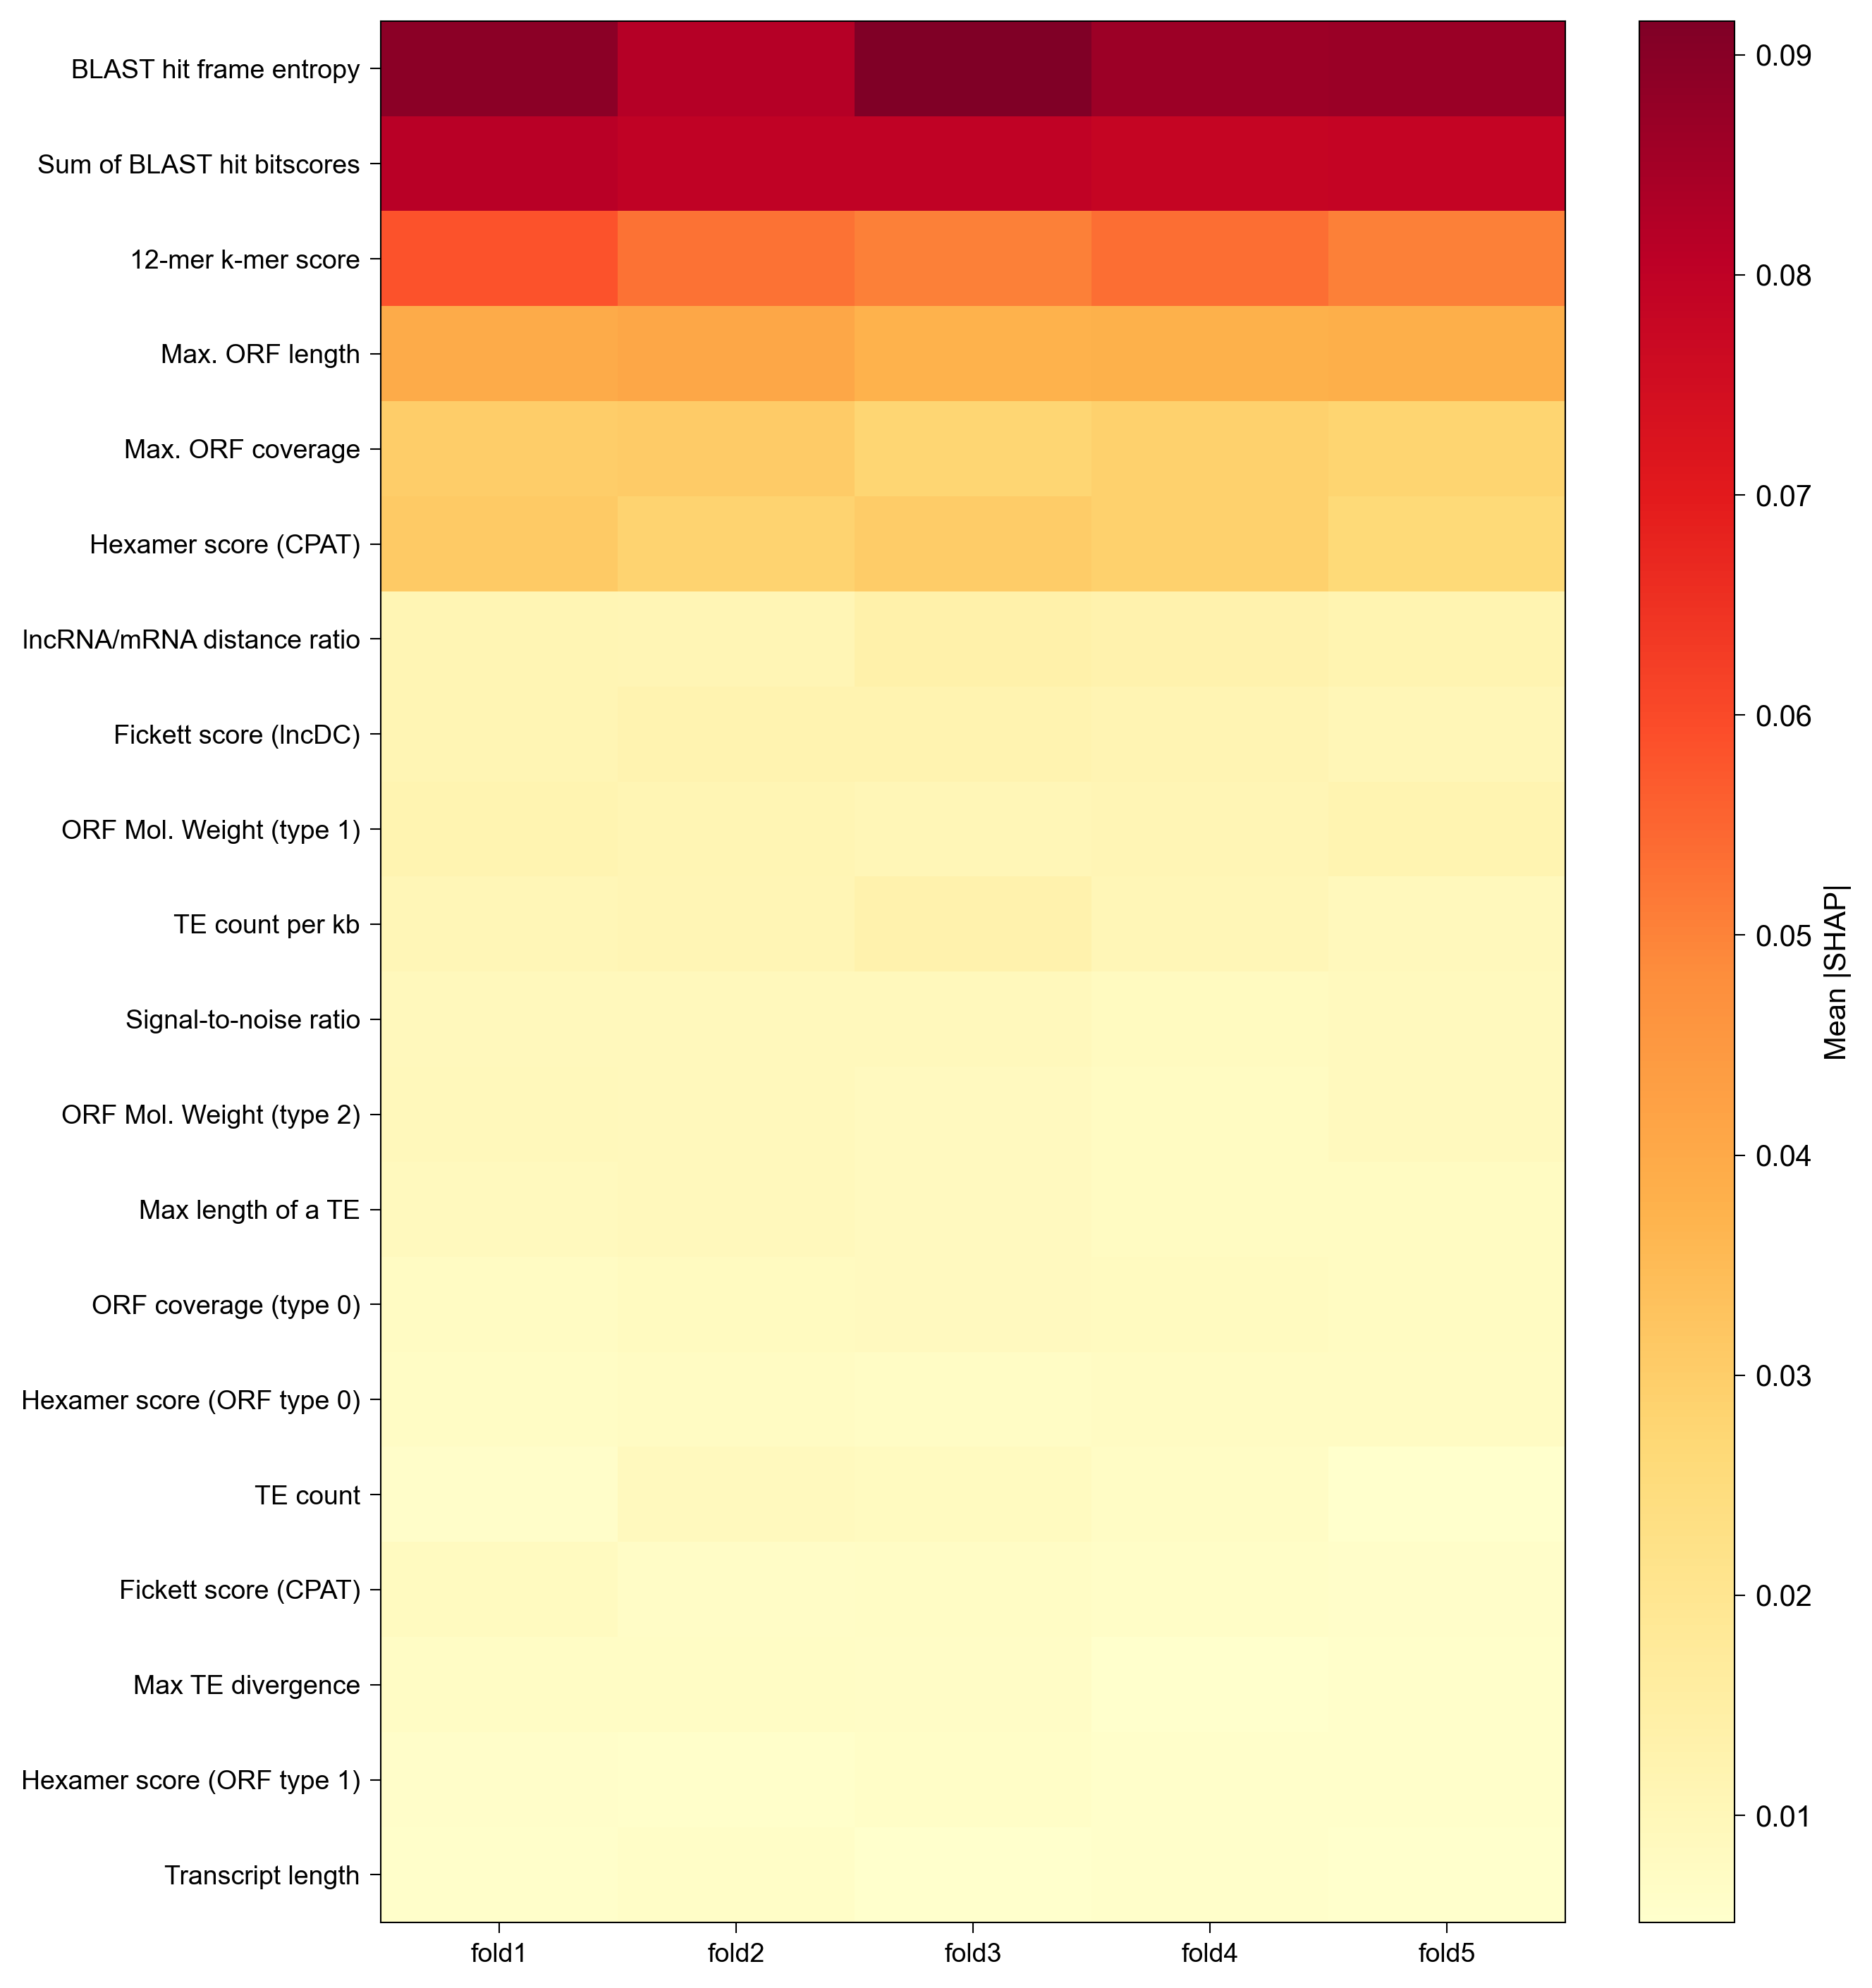

In [ ]:
top_feats      = shap_agg.head(TOP_N).index
data           = per_fold_mean_abs[top_feats].T   # features × folds
n_folds_loaded = per_fold_mean_abs.shape[0]

fig, ax = plt.subplots(figsize=(n_folds_loaded * 1.4 + 2, TOP_N * 0.4 + 1.5), dpi=300)
im = ax.imshow(data.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(n_folds_loaded))
ax.set_xticklabels(per_fold_mean_abs.index, fontsize=9)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels([FEATURE_LABEL_DICT.get(f, f) for f in top_feats], fontsize=9)
plt.colorbar(im, ax=ax, label="Mean |SHAP|")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_fold_heatmap.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


#### Plot 9d – Beeswarm (all transcripts pooled)
*Source: cell 17*

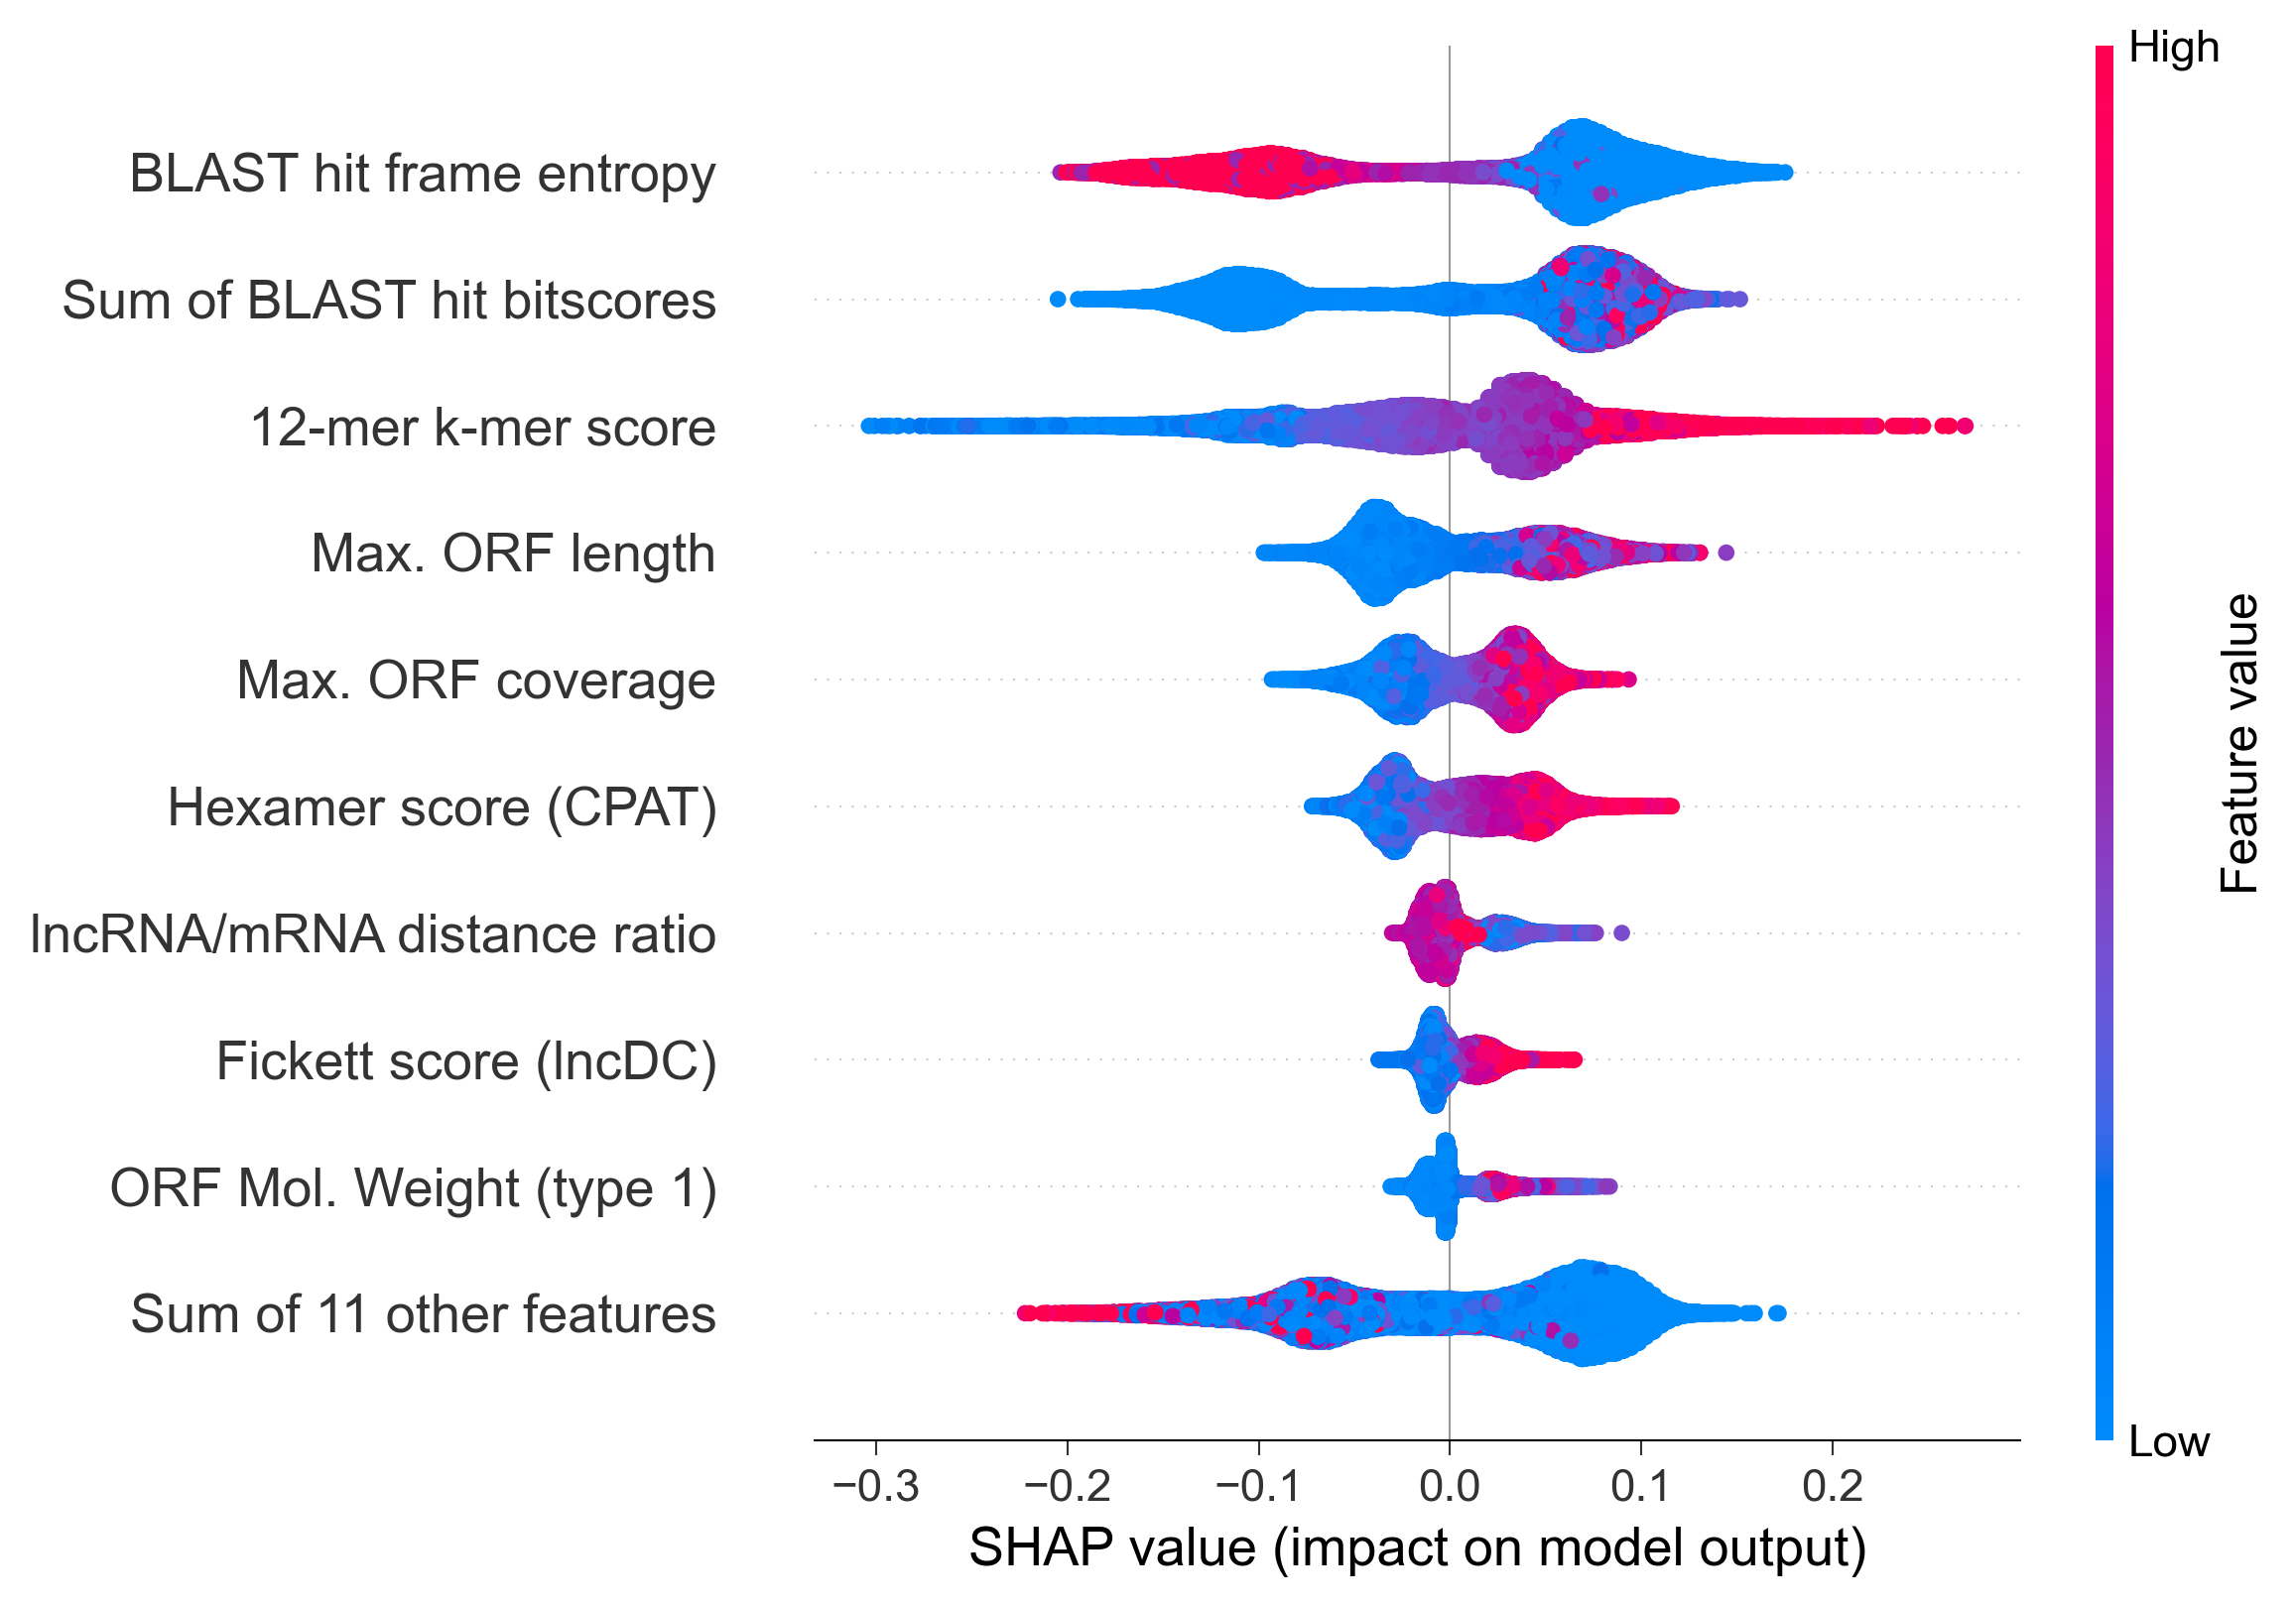

In [ ]:
all_sv, all_xv = [], []
for res in fold_data.values():
    sv = res["shap_df"].reindex(columns=top_feats, fill_value=0).values
    xv = res["X_test"].reindex(columns=top_feats, fill_value=0).values
    all_sv.append(sv)
    all_xv.append(xv)

sv_mat = np.vstack(all_sv)
x_mat  = np.vstack(all_xv)
expl_beeswarm = shap.Explanation(
    values=sv_mat, data=x_mat,
    feature_names=[FEATURE_LABEL_DICT.get(f, f) for f in top_feats]
)

fig = plt.figure(figsize=(10, 6), dpi=300)
shap.plots.beeswarm(expl_beeswarm, show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_beeswarm_all_transcripts.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


#### Plot 9e – Predicted probability distribution
*Source: cell 19*

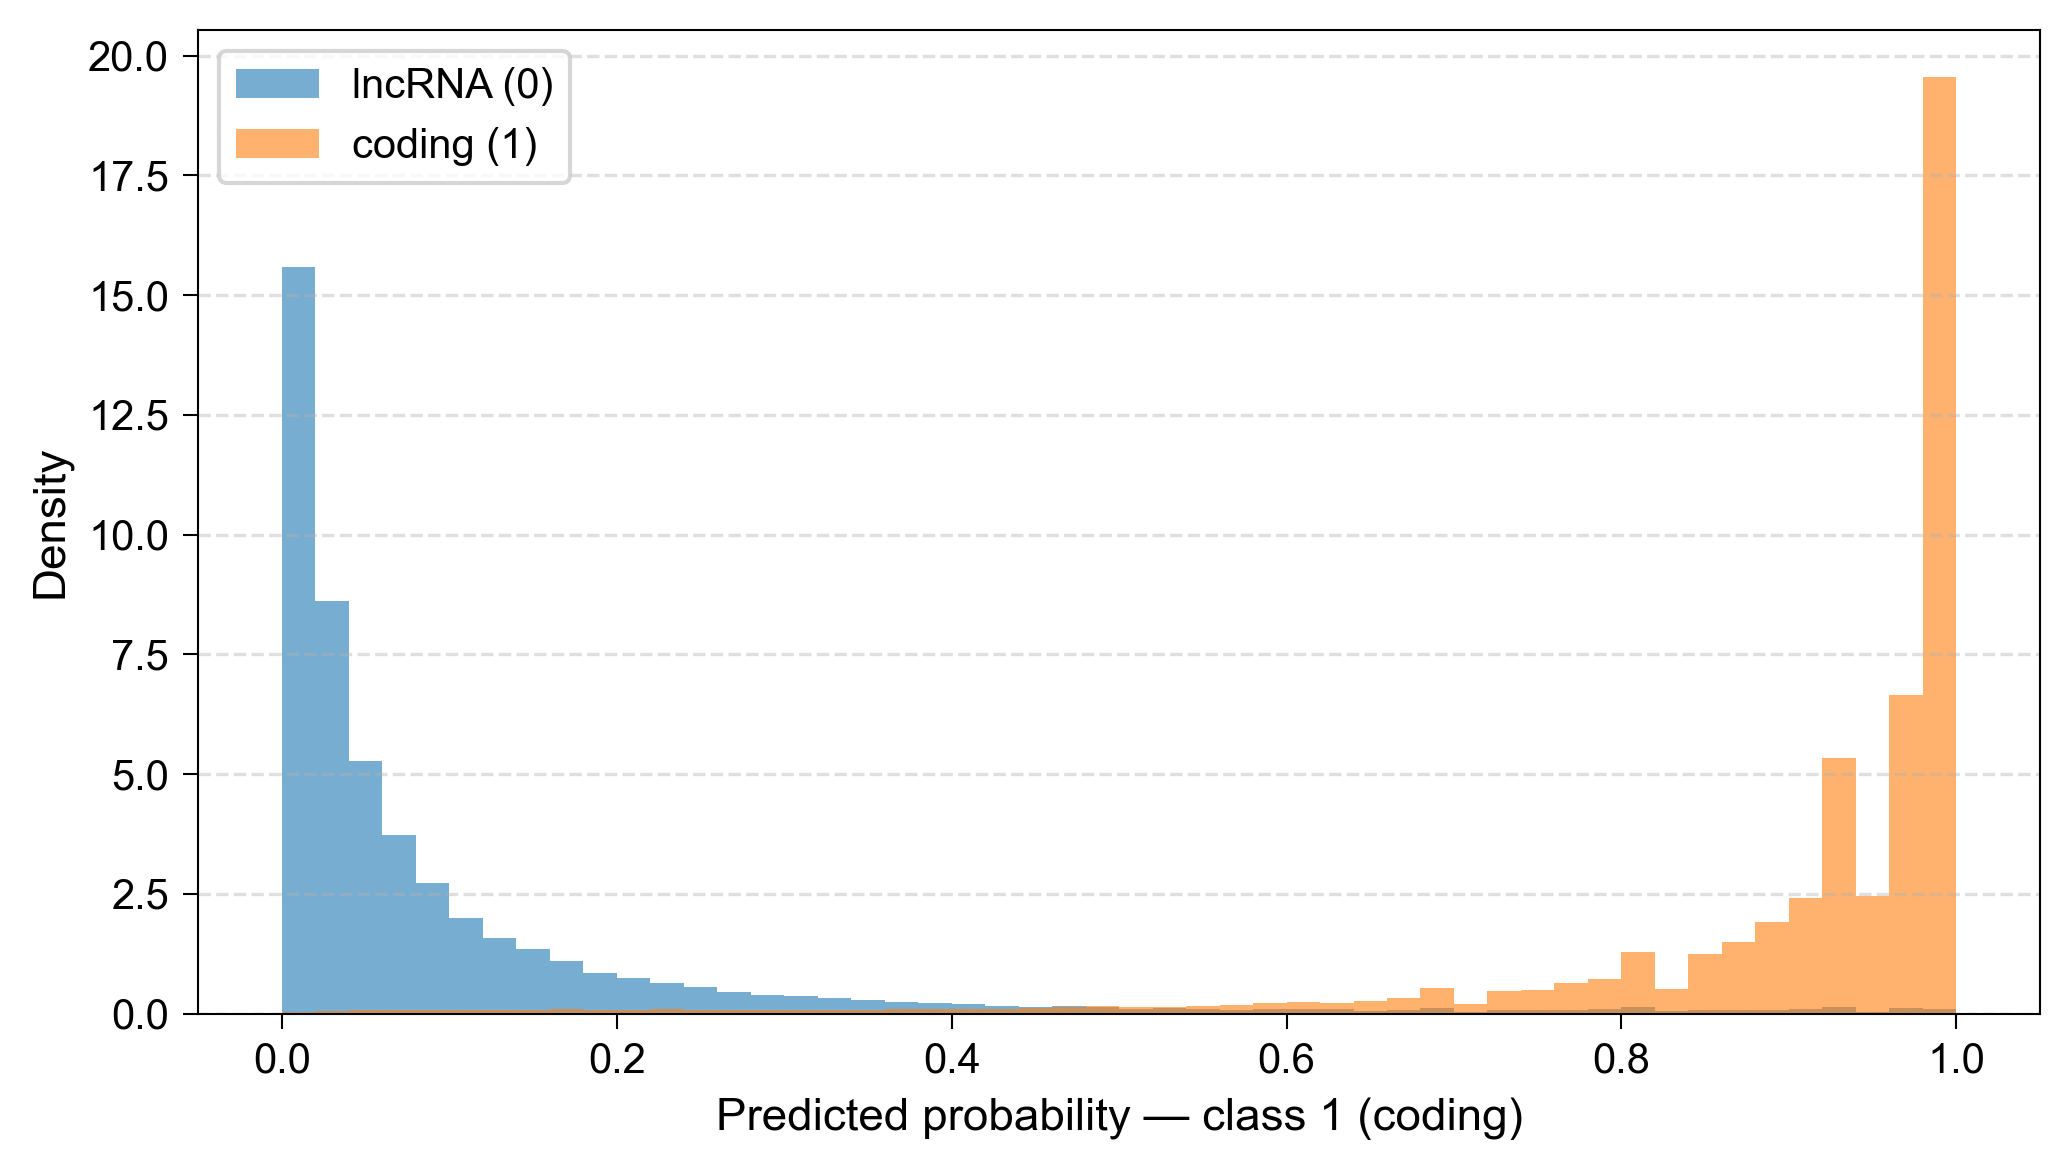

In [ ]:
prob_col = "y_pred_proba_class_1"

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
for label, grp in combined_preds.groupby("y_true"):
    clsname = "coding (1)" if label == 1 else "lncRNA (0)"
    ax.hist(grp[prob_col], bins=50, alpha=0.6, label=clsname, density=True)
ax.set_xlabel("Predicted probability — class 1 (coding)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_prediction_probability_distribution.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()


#### Plot 9f – Waterfall plots (cherry-picked transcripts)
*Source: cell 26*

In [ ]:
# ── Cherry-pick definitions ───────────────────────────────────────────────────
cherry_pick = {
    "low_entropy_coding":  ["ENST00000265171"],
    "low_entropy_lncrna":  ["ENST00000710870"],
    "high_entropy_coding": ["ENST00000608796"],
    "high_entropy_lncrna": ["ENST00000524131"],
}
cherry_names = {
    "low_entropy_coding":  ["EGF"],
    "low_entropy_lncrna":  ["MALAT1"],
    "high_entropy_coding": ["SWI5"],
    "high_entropy_lncrna": ["MEG3"],
}
group_titles = {
    "low_entropy_coding":  "Low-entropy coding",
    "low_entropy_lncrna":  "Low-entropy lncRNA",
    "high_entropy_coding": "High-entropy coding",
    "high_entropy_lncrna": "High-entropy lncRNA",
}

WATERFALL_MAX_DISPLAY = 11
WATERFALL_W_CM        = 8.0
WATERFALL_H_CM        = 4.0

def build_transcript_index(fold_data):
    index = {}
    for fold_i, res in fold_data.items():
        for full_id in res["shap_df"].index:
            index[full_id.split(".")[0]] = (fold_i, full_id)
    return index

def get_shap_row(tid, index, fold_data):
    short = tid.split(".")[0]
    if short not in index:
        return None, None, None
    fold_i, full_id = index[short]
    return fold_data[fold_i]["shap_df"].loc[full_id], fold_i, full_id

transcript_index = build_transcript_index(fold_data)

# Verify
for group, tids in cherry_pick.items():
    for tid, name in zip(tids, cherry_names[group]):
        found = tid.split(".")[0] in transcript_index
        print(f"  {'✓' if found else '✗'}  {group:25s}  {tid}  ({name})")


  ✓  low_entropy_coding         ENST00000265171  (EGF)
  ✓  low_entropy_lncrna         ENST00000710870  (MALAT1)
  ✓  high_entropy_coding        ENST00000608796  (SWI5)
  ✓  high_entropy_lncrna        ENST00000524131  (MEG3)


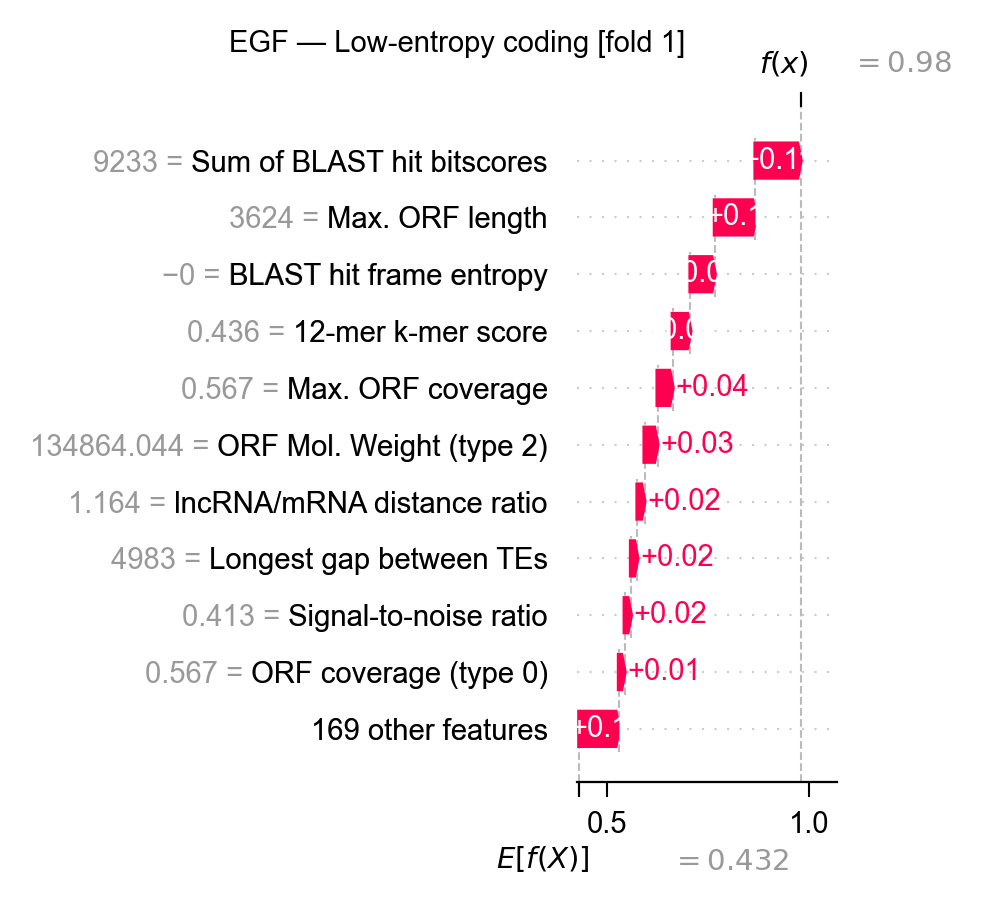

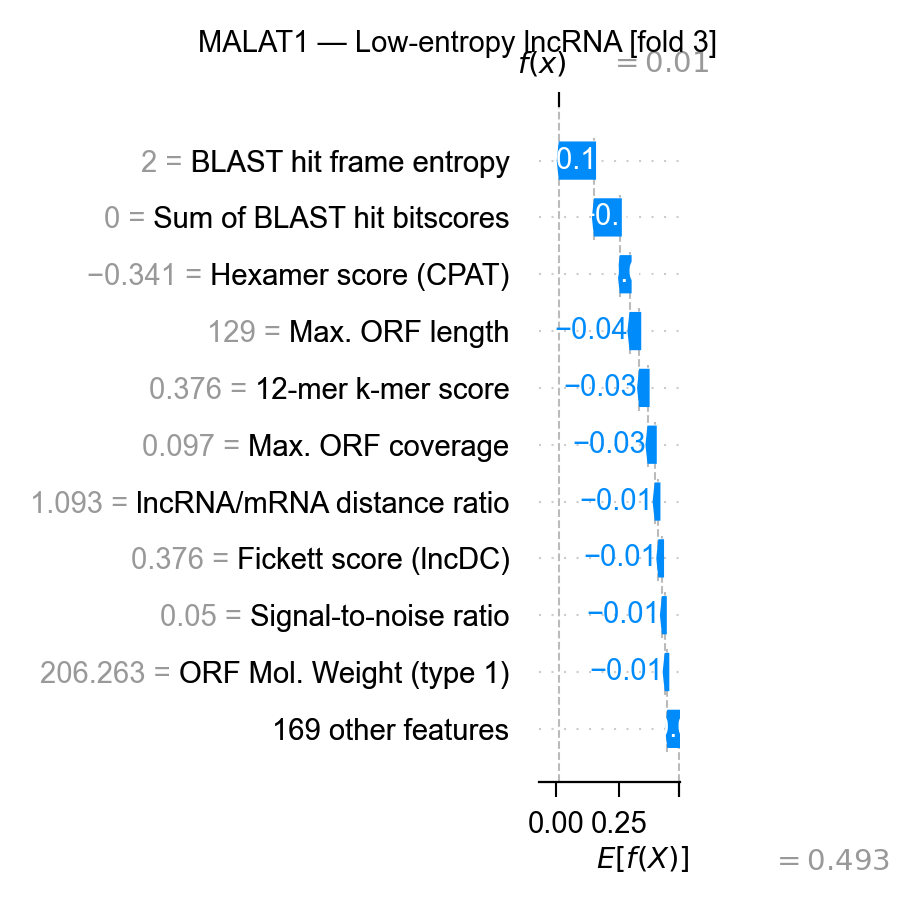

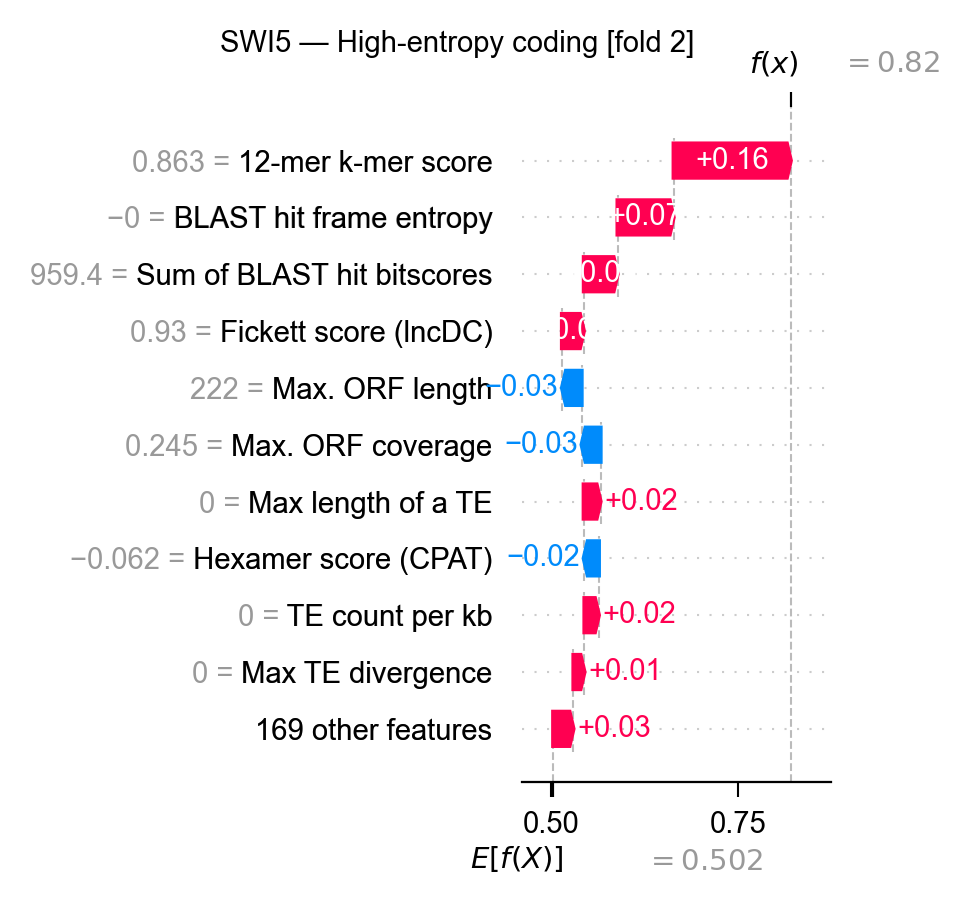

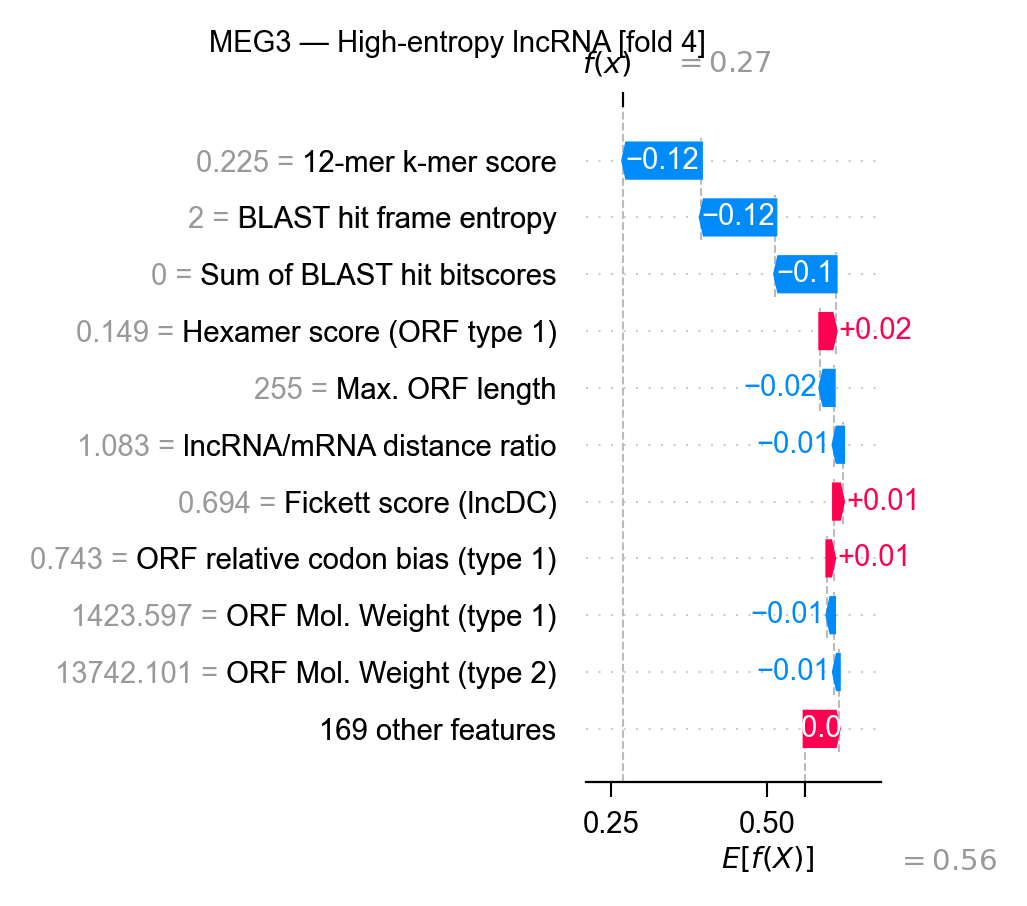

In [ ]:
from unittest.mock import patch

TARGET_ROW_HEIGHT = 0.3   # compact rows

for group, tids in cherry_pick.items():
    names = cherry_names[group]
    for tid, gene_name in zip(tids, names):
        shap_s, fold_i, full_id = get_shap_row(tid, transcript_index, fold_data)
        if shap_s is None:
            print(f"SKIP {tid} ({gene_name}) — not in any test fold")
            continue

        res = fold_data[fold_i]
        x_row = res["X_test"].loc[full_id]
        readable_feats = [FEATURE_LABEL_DICT.get(f, f) for f in shap_s.index.tolist()]

        expl = shap.Explanation(
            values=shap_s.values,
            base_values=res["base_val"],
            data=x_row.values,
            feature_names=readable_feats,
        )

        _orig_arrow = plt.arrow

        def _patched_arrow(*args, **kwargs):
            kwargs["width"]      = 0.6
            kwargs["head_width"] = 0.6
            return _orig_arrow(*args, **kwargs)

        plt.arrow = _patched_arrow

        fig = plt.figure(figsize=(WATERFALL_W_CM / 2.54, WATERFALL_H_CM / 2.54), dpi=300)
        shap.plots.waterfall(expl, max_display=WATERFALL_MAX_DISPLAY, show=False)
        fig.suptitle(f"{gene_name} — {group_titles[group]} [fold {fold_i}]", fontsize=7, y=0.9)

        plt.arrow = _orig_arrow

        n = min(WATERFALL_MAX_DISPLAY, len(shap_s.values))
        plt.gcf().set_size_inches(WATERFALL_W_CM / 2.54, n * TARGET_ROW_HEIGHT)

        for ax in fig.axes:
            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontsize(7)
            for txt in ax.texts:
                txt.set_fontsize(7)
            ax.xaxis.label.set_size(7)
            ax.yaxis.label.set_size(7)

        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"shap_waterfall_{group}_{gene_name}.pdf",
                    dpi=300, format="pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)
